# SAML-D 상세 탐색적 데이터 분석 (EDA)

**원본 전체를 직접 분석하는 실행형 노트북**입니다. 각 절의 설명 → 코드 → 표·그래프 → 해석 순서로 읽습니다. 기존 CSV 집계 파일을 불러오는 대신 `/workspace/SAML-D.csv`에서 다시 계산합니다.

- 실행: **Kernel → Restart Kernel and Run All Cells**. 다른 환경에서는 첫 설정 셀의 `SOURCE`를 수정합니다.
- 필요 패키지: `duckdb`, `pandas`, `numpy`, `matplotlib`, `ipykernel`. 누락 시 노트북에서 `%pip install duckdb pandas numpy matplotlib ipykernel`을 실행한 뒤 커널을 재시작합니다.
- 원본은 약 950만 행·1 GB입니다. 전체 데이터를 pandas에 올리지 않고 DuckDB로 집계하며, 그래프에는 집계표 또는 명시된 표본만 사용합니다.
- 임시 DB는 `/tmp`, 표·PNG·PDF는 노트북 옆 `notebook_outputs/`에 생성됩니다. **원본 데이터와 기존 학습 설정은 수정하지 않습니다.**
- 전체 원본을 탐색하는 노트북입니다. 결과를 학습 피처나 정규화 계수로 사용하려면 별도의 시간 분할이 필요합니다.

### 구성
1. 환경·입력 및 스키마 / 2. 품질·라벨 / 3. 시간·유형 / 4. 통화·금액·지급 방식 / 5. 위치·계좌·거래 관계 / 6. 중복·충돌 / 7. 시간 분할 점검 / 8. 검증·요약

**표별 셀 구성:** 각 표와 그래프를 별도 코드 셀로 분리했습니다. 필요한 절까지 위에서 순서대로 실행한 뒤, 관심 있는 표·그래프 셀만 다시 실행할 수 있습니다.

**한글화 안내:** 표 컬럼·범주·그래프·출력 메시지를 한글로 표시합니다. `조회()`는 SQL 집계, `표보기()`는 한글 표 출력, `그림저장()`은 그래프 출력·저장 함수입니다. SQL과 원본 영문 컬럼은 유지하며, CSV는 기존 코드와 호환되도록 원래 컬럼명으로 저장합니다. 다른 PC로 옮길 때 `assets/` 폴더도 함께 복사하세요.

**패턴 표기:** 양성 거래 유형은 원본 영문 이름으로 표시합니다. 그 외 표·그래프 설명과 정상 유형 표기는 한글로 유지합니다.

## 1. 실행 환경과 입력 설정
`SOURCE`만 바꾸면 다른 위치의 동일 스키마 CSV도 분석할 수 있습니다. 계좌 ID를 숫자로 변환하지 않고 문자열로 보존합니다. 설명·출력 표·그래프를 한글로 표시합니다. 원본 컬럼명과 SQL 문법은 호환성을 위해 유지하고 한국어 주석으로 뜻을 설명합니다.

DB 이름은 커널 프로세스별로 분리해 기존 EDA·학습과 충돌하지 않게 합니다. 첫 셀을 다시 실행하면 현재 노트북의 이전 DB 연결을 닫습니다. 임시 DB는 원본에서 언제든 재생성할 수 있습니다.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import sys, os, json, time, hashlib, importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# 이 서버의 기존 설치 위치를 보조 검색합니다. 다른 PC에서는 pip 설치를 사용하세요.
if importlib.util.find_spec('duckdb') is None:
    local_site = Path('/workspace/kimi/CODEX/.venv/lib/python3.12/site-packages')
    if local_site.exists():
        sys.path.append(str(local_site))
import duckdb

SOURCE = Path('/workspace/SAML-D.csv')
PROJECT_OUTPUT = Path('/workspace/kimi/Claude_GNN/final_model/raw_eda/saml_d')
OUTPUT = (PROJECT_OUTPUT if PROJECT_OUTPUT.is_dir() else Path.cwd()) / 'notebook_outputs'
OUTPUT.mkdir(parents=True, exist_ok=True)
WORK = Path('/tmp') / f'saml_d_notebook_{os.getpid()}'
WORK.mkdir(exist_ok=True)
assert SOURCE.is_file(), f'원본 경로를 확인하세요: {SOURCE}'
if 'con' in globals():
    con.close()
con = duckdb.connect(str(WORK / 'eda.duckdb'))
con.execute("SET memory_limit='2GB'")
con.execute('SET threads=2')
con.execute("SET temp_directory='" + str(WORK / 'spill').replace("'", "''") + "'")
START = time.time()
SOURCE_STAT = (SOURCE.stat().st_size, SOURCE.stat().st_mtime_ns)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': False})
pd.set_option('display.max_columns', 30)

def sqlstr(value):
    return "'" + str(value).replace("'", "''") + "'"

def ident(value):
    return '"' + str(value).replace('"', '""') + '"'

def 조회(sql, name=None):
    """SQL로 전체 데이터를 집계하고 필요하면 CSV로 저장합니다."""
    frame = con.execute(sql).fetchdf()
    if name:
        frame.to_csv(OUTPUT / f'{name}.csv', index=False, encoding='utf-8-sig')
    return frame

def 그림저장(name):
    """제목·축·범례를 한글로 표시하고 PNG/PDF를 저장합니다."""
    from matplotlib.text import Text
    plt.gcf().canvas.draw()
    for 축 in plt.gcf().axes:
        for 방향 in ["x", "y"]:
            눈금 = getattr(축, f"get_{방향}ticks")()
            기존문구 = [t.get_text() for t in getattr(축, f"get_{방향}ticklabels")()]
            번역문구 = [한글(t) for t in 기존문구]
            if 번역문구 != 기존문구:
                getattr(축, f"set_{방향}ticks")(눈금, 번역문구)
    for 문구 in plt.gcf().findobj(match=Text):
        문구.set_text(한글(문구.get_text()))
    plt.gcf().tight_layout()
    plt.gcf().savefig(OUTPUT / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.gcf().savefig(OUTPUT / f'{name}.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

print('원본 파일:', SOURCE, '| 크기:', round(SOURCE_STAT[0] / 1024**2, 1), 'MiB')
print('결과 저장 폴더:', OUTPUT)
print('DuckDB:', duckdb.__version__, '| pandas:', pd.__version__)

원본 파일: /workspace/SAML-D.csv | 크기: 950.0 MiB
결과 저장 폴더: /workspace/kimi/Claude_GNN/final_model/raw_eda/saml_d/notebook_outputs
DuckDB: 1.5.5 | pandas: 3.0.3


### 한글 표시 도구와 글꼴

이 셀은 표·그래프에 사용할 한글 이름 사전과 글꼴을 준비합니다. 긴 사전은 표시용 설정이므로 분석할 때는 실행만 하고 다음 셀로 넘어가도 됩니다. **원본 데이터와 계산용 영문 컬럼명은 유지**합니다. 유형 번역은 이해를 돕는 표시명이며 세부 생성 규칙을 확정하는 정의가 아닙니다.

In [2]:
# 화면에 표시할 이름만 번역합니다. 계산용 데이터와 원본 값은 변경하지 않습니다.
한글이름 = {
    'Time': '시각',
    'Date': '날짜',
    'Sender_account': '송신 계좌 ID',
    'Receiver_account': '수신 계좌 ID',
    'Amount': '원본 금액',
    'Payment_currency': '지급 통화',
    'Received_currency': '수취 통화',
    'Sender_bank_location': '송신 은행 위치',
    'Receiver_bank_location': '수신 은행 위치',
    'Payment_type': '지급 방식',
    'Is_laundering': '세탁 여부 원본',
    'Laundering_type': '거래 유형',
    'row_id': '원본 행 번호',
    'ts': '변환된 거래 일시',
    'amount_num': '숫자로 변환한 금액',
    'y': '정답(0 정상·1 양성)',
    'column_name': '컬럼 이름',
    'column_type': '자료형',
    'null': '결측 허용',
    'key': '키',
    'default': '기본값',
    'extra': '추가 정보',
    'VARCHAR': '문자열',
    'BIGINT': '큰 정수',
    'INTEGER': '정수',
    'DOUBLE': '실수',
    'TIMESTAMP': '날짜·시간',
    'YES': '허용',
    'NO': '불허',
    'column': '컬럼',
    'nulls': '결측 수',
    'blank': '공백만 있는 행',
    'null_like': '결측 유사 문자열',
    'outer_spaces': '앞뒤 공백',
    'unique': '고유값 수',
    'rows': '전체 거래 수',
    'first_timestamp': '첫 거래 일시',
    'last_timestamp': '마지막 거래 일시',
    'positives': '양성 거래 수',
    'negatives': '정상 거래 수',
    'invalid_datetime': '날짜·시간 변환 실패',
    'invalid_amount': '금액 변환 실패·비유한값',
    'invalid_label': '비정상 정답',
    'negative_amount': '음수 금액',
    'zero_amount': '0원 거래',
    'self_transfers': '자기 계좌 거래',
    'value': '값',
    'role': '역할',
    'sender': '송신',
    'receiver': '수신',
    'non_digits': '숫자 외 문자 포함 행',
    'leading_zero': '선행 0이 있는 행',
    'unique_ids': '고유 계좌 ID 수',
    'transactions': '거래 수',
    'percent': '전체 대비 비율(%)',
    'positive_pct': '양성 비율(%)',
    'day': '날짜',
    'first_time': '당일 첫 거래',
    'last_time': '당일 마지막 거래',
    'month': '월',
    'hour': '시간대',
    'weekday': '요일',
    'category': '범주',
    'minimum': '최솟값',
    'p01': '1백분위수',
    'p25': '25백분위수',
    'median': '중앙값',
    'p75': '75백분위수',
    'p95': '95백분위수',
    'p99': '99백분위수',
    'p999': '99.9백분위수',
    'maximum': '최댓값',
    'mean': '평균',
    'above_upper_iqr': 'IQR 상단 초과 거래',
    'above_p99': '99백분위수 초과 거래',
    'positives_above_p99': '99백분위수 초과 양성',
    'source': '송신·지급 범주',
    'destination': '수신·수취 범주',
    'currency_change': '통화 변경 여부',
    'location_change': '은행 위치 변경 여부',
    'unique_accounts': '전체 고유 계좌 ID',
    'both_roles': '송수신 모두 등장한 ID',
    'multiple_locations': '여러 위치에 등장한 ID',
    'median_activity': '계좌 활동 중앙값',
    'max_activity': '계좌 활동 최댓값',
    'account': '계좌 ID',
    'endpoint_count': '송수신 등장 횟수',
    'sent': '송신 건수',
    'received': '수신 건수',
    'positive_endpoints': '양성 거래의 계좌 등장 횟수',
    'locations': '관측 위치 수',
    'accounts': '계좌 수',
    'bucket': '구간',
    'directed_pairs': '방향성 계좌 쌍 수',
    'single_transaction_pairs': '1회 거래 계좌 쌍',
    'median_pair_transactions': '쌍별 거래 수 중앙값',
    'max_pair_transactions': '쌍별 거래 수 최댓값',
    'transactions_at_same_second': '같은 초의 거래 수',
    'timestamp_groups': '해당 시각 그룹 수',
    'duplicate_groups': '완전 중복 그룹 수',
    'extra_rows': '중복 초과 행 수',
    'involved_rows': '중복 관련 전체 행',
    'repeated_input_groups': '반복 입력 그룹 수',
    'conflicting_binary_labels': '이진 정답 충돌 그룹',
    'multiple_types': '유형이 여러 개인 그룹',
    'example_split': '예시 분할',
    'split': '분할',
    'start': '시작일',
    'end': '종료일',
    'days': '날짜 수',
    'row_share_pct': '거래 건수 비중(%)',
    'train': '학습',
    'val': '검증',
    'test': '테스트',
    'Train': '학습',
    'Val': '검증',
    'Test': '테스트',
    'passed': '검사 통과',
    'label_counts': '라벨별 건수 합계',
    'type_counts': '유형별 건수 합계',
    'type_positive_counts': '유형별 양성 합계',
    'daily_valid_timestamp_counts': '일별 유효 날짜 건수',
    'currency_counts': '통화별 건수 합계',
    'payment_counts': '지급 방식별 건수 합계',
    'amount_valid_counts': '유효 금액 건수 합계',
    'source_unchanged': '원본 변경 없음',
    'Credit card': '신용카드',
    'Debit card': '직불카드',
    'Cheque': '수표',
    'ACH': '자동이체(ACH)',
    'Cross-border': '국경 간 거래',
    'Cash Withdrawal': '현금 인출',
    'Cash Deposit': '현금 입금',
    'UK pounds': '영국 파운드',
    'Euro': '유로',
    'Turkish lira': '튀르키예 리라',
    'Swiss franc': '스위스 프랑',
    'Dirham': '디르함',
    'Pakistani rupee': '파키스탄 루피',
    'Naira': '나이지리아 나이라',
    'US dollar': '미국 달러',
    'Yen': '일본 엔',
    'Moroccan dirham': '모로코 디르함',
    'Mexican Peso': '멕시코 페소',
    'Albanian lek': '알바니아 레크',
    'Indian rupee': '인도 루피',
    'UK': '영국',
    'Turkey': '튀르키예',
    'Switzerland': '스위스',
    'Pakistan': '파키스탄',
    'UAE': '아랍에미리트',
    'Nigeria': '나이지리아',
    'Spain': '스페인',
    'Germany': '독일',
    'USA': '미국',
    'Italy': '이탈리아',
    'France': '프랑스',
    'Japan': '일본',
    'Morocco': '모로코',
    'Austria': '오스트리아',
    'Mexico': '멕시코',
    'Albania': '알바니아',
    'India': '인도',
    'Netherlands': '네덜란드',
    'Behavioural_Change_1': 'Behavioural_Change_1',
    'Behavioural_Change_2': 'Behavioural_Change_2',
    'Bipartite': 'Bipartite',
    'Cash_Withdrawal': 'Cash_Withdrawal',
    'Cycle': 'Cycle',
    'Deposit-Send': 'Deposit-Send',
    'Fan_In': 'Fan_In',
    'Fan_Out': 'Fan_Out',
    'Gather-Scatter': 'Gather-Scatter',
    'Layered_Fan_In': 'Layered_Fan_In',
    'Layered_Fan_Out': 'Layered_Fan_Out',
    'Normal_Cash_Deposits': '정상 현금 입금',
    'Normal_Cash_Withdrawal': '정상 현금 인출',
    'Normal_Fan_In': '정상 다수→단일 유입',
    'Normal_Fan_Out': '정상 단일→다수 유출',
    'Normal_Foward': '정상 전달',
    'Normal_Group': '정상 그룹',
    'Normal_Mutual': '정상 상호 거래',
    'Normal_Periodical': '정상 주기 거래',
    'Normal_Plus_Mutual': '정상 추가 상호 거래',
    'Normal_Small_Fan_Out': '정상 소규모 분산',
    'Normal_single_large': '정상 단일 고액',
    'Over-Invoicing': 'Over-Invoicing',
    'Scatter-Gather': 'Scatter-Gather',
    'Single_large': 'Single_large',
    'Smurfing': 'Smurfing',
    'Stacked Bipartite': 'Stacked Bipartite',
    'Structuring': 'Structuring',
    'Rows': '행 수',
    'Full-data quality checks (zero means none found)': '전체 데이터 품질 검사 (0이면 발견 없음)',
    'Transactions (log scale)': '거래 수 (로그 축)',
    'Label: 0 normal, 1 laundering': '정답: 0 정상, 1 자금세탁 양성',
    'Percent of all transactions': '전체 거래 대비 비율(%)',
    'Daily volume, positive count and positive rate (%)': '일별 전체 거래·양성 거래·양성 비율',
    'Hour': '시간대',
    'Positive rate (%)': '양성 비율(%)',
    'Mon': '월',
    'Tue': '화',
    'Wed': '수',
    'Thu': '목',
    'Fri': '금',
    'Sat': '토',
    'Sun': '일',
    'Transactions': '거래 수',
    'Positive type share within each month (%)': '월별 양성 유형 구성비(%)',
    '% of monthly positives': '해당 월 양성 중 비율(%)',
    'log10(1 + amount)': 'log10(1 + 금액)',
    'Within-class density': '클래스별 확률 밀도',
    'log10(1 + transactions)': 'log10(1 + 거래 수)',
    'Accounts (log scale)': '계좌 수 (로그 축)',
    'Endpoint appearances': '송수신 등장 횟수',
    'Distinct locations per account ID': '계좌 ID별 관측 위치 수',
    'Transactions at one timestamp': '같은 시각의 거래 수',
    'Timestamp groups (log scale)': '시각 그룹 수 (로그 축)',
    'Daily positive rate (%)': '일별 양성 비율(%)',
    'Illustrative chronological split (not a training configuration)': '시간순 분할 예시 (실제 학습 설정 아님)',
}

def 한글(value):
    """알려진 컬럼·범주·그래프 문구를 한글로 표시합니다."""
    if isinstance(value, str):
        return 한글이름.get(value, value)
    return value

def 표보기(value):
    """표의 복사본에만 한글 컬럼명과 범주명을 적용해 출력합니다."""
    if not isinstance(value, pd.DataFrame):
        display(value)
        return
    보기 = value.copy()
    for 컬럼 in 보기.columns:
        if str(보기[컬럼].dtype) in ('object', 'str', 'string'):
            보기[컬럼] = 보기[컬럼].map(한글)
    원래열축 = 보기.columns.name
    보기.columns = [한글(x) for x in 보기.columns]
    if 원래열축 == 'y':
        보기.columns = ['정상(0)' if x == 0 else '양성(1)' if x == 1 else x for x in 보기.columns]
    보기.columns.name = 한글(원래열축)
    보기.index = 보기.index.map(한글)
    보기.index.name = 한글(value.index.name)
    display(보기)

# 한글 글꼴은 노트북과 함께 제공한 assets 폴더에서 읽습니다.
from matplotlib import font_manager
글꼴후보 = [PROJECT_OUTPUT / 'assets/NotoSansKR.ttf', Path.cwd() / 'assets/NotoSansKR.ttf']
글꼴경로 = next((p for p in 글꼴후보 if p.is_file()), None)
if 글꼴경로 is not None:
    font_manager.fontManager.addfont(str(글꼴경로))
    plt.rcParams['font.family'] = font_manager.FontProperties(fname=str(글꼴경로)).get_name()
else:
    설치글꼴 = {f.name for f in font_manager.fontManager.ttflist}
    대체글꼴 = next((x for x in ['Noto Sans KR','NanumGothic','Malgun Gothic','AppleGothic'] if x in 설치글꼴), None)
    if 대체글꼴 is None:
        raise FileNotFoundError('한글 글꼴이 없습니다. 노트북과 함께 assets/NotoSansKR.ttf를 복사해 주세요.')
    plt.rcParams['font.family'] = 대체글꼴
plt.rcParams['axes.unicode_minus'] = False
print('한글 표·그래프 표시 준비 완료')


한글 표·그래프 표시 준비 완료


## 2. 전체 CSV 읽기와 컬럼 확인
모든 원본 컬럼을 문자열로 읽어 결측·문자 혼입을 먼저 검사합니다. CSV 파싱 오류는 무시하지 않습니다. 날짜·금액·라벨은 별도 컬럼으로 변환하며, 원본 값도 남깁니다. `row_id`는 이 분석 내부의 행 식별자입니다.

`Laundering_type`은 정답 성격의 메타데이터입니다. 계좌 ID는 연속형 측정값이 아니므로 평균·표준편차를 계산할 대상이 아닙니다.

### 2-1. 원본 읽기·변환 및 스키마 표

CSV 전체를 읽고 날짜·금액·라벨을 파생 컬럼으로 만듭니다. 표에서 원본 문자열과 변환된 자료형을 확인하세요.

In [3]:
# 2-1. 원본 읽기·변환 및 스키마 표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
con.execute(f"CREATE OR REPLACE TABLE raw AS SELECT row_number() OVER () - 1 AS row_id, * FROM read_csv({sqlstr(SOURCE)}, header=true, all_varchar=true, strict_mode=true, ignore_errors=false)")
columns = [r[0] for r in con.execute('DESCRIBE raw').fetchall() if r[0] != 'row_id']
expected = ['Time','Date','Sender_account','Receiver_account','Amount',
            'Payment_currency','Received_currency','Sender_bank_location',
            'Receiver_bank_location','Payment_type','Is_laundering','Laundering_type']
assert columns == expected, f'예상하지 못한 스키마: {columns}'
con.execute("""CREATE OR REPLACE TABLE tx AS SELECT *,
    try_strptime(Date || ' ' || Time, '%Y-%m-%d %H:%M:%S') AS ts,
    try_cast(Amount AS DOUBLE) AS amount_num,
    CASE WHEN trim(Is_laundering) IN ('0','1') THEN cast(trim(Is_laundering) AS INTEGER) END AS y
    FROM raw""")
N = con.execute('SELECT count(*) FROM tx').fetchone()[0]
표보기(조회('DESCRIBE tx'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,컬럼 이름,자료형,결측 허용,키,기본값,추가 정보
0,원본 행 번호,큰 정수,허용,None,None,None
1,시각,문자열,허용,None,None,None
2,날짜,문자열,허용,None,None,None
3,송신 계좌 ID,문자열,허용,None,None,None
4,수신 계좌 ID,문자열,허용,None,None,None
5,원본 금액,문자열,허용,None,None,None
6,지급 통화,문자열,허용,None,None,None
7,수취 통화,문자열,허용,None,None,None
8,송신 은행 위치,문자열,허용,None,None,None
9,수신 은행 위치,문자열,허용,None,None,None


### 2-2. 원본 행과 변환 결과 예시

처음 5개 행만 표시합니다. 이 표는 형식 확인용이며 전체 분포를 대표하지 않습니다.

In [4]:
# 2-2. 원본 행과 변환 결과 예시
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
표보기(조회('SELECT * FROM tx ORDER BY row_id LIMIT 5'))
print(f'전체 거래: {N:,}건 / 원본 컬럼: {len(columns)}개')

,원본 행 번호,시각,날짜,송신 계좌 ID,수신 계좌 ID,원본 금액,지급 통화,수취 통화,송신 은행 위치,수신 은행 위치,지급 방식,세탁 여부 원본,거래 유형,변환된 거래 일시,숫자로 변환한 금액,정답(0 정상·1 양성)
0,0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,영국 파운드,영국 파운드,영국,영국,현금 입금,0,정상 현금 입금,2022-10-07 10:35:19,1459.15,0
1,1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,영국 파운드,디르함,영국,아랍에미리트,국경 간 거래,0,정상 단일→다수 유출,2022-10-07 10:35:20,6019.64,0
2,2,10:35:20,2022-10-07,287305149,4404767002,14328.44,영국 파운드,영국 파운드,영국,영국,수표,0,정상 소규모 분산,2022-10-07 10:35:20,14328.44,0
3,3,10:35:21,2022-10-07,5376652437,9600420220,11895.0,영국 파운드,영국 파운드,영국,영국,자동이체(ACH),0,정상 다수→단일 유입,2022-10-07 10:35:21,11895.00,0
4,4,10:35:21,2022-10-07,9614186178,3803336972,115.25,영국 파운드,영국 파운드,영국,영국,현금 입금,0,정상 현금 입금,2022-10-07 10:35:21,115.25,0


전체 거래: 9,504,852건 / 원본 컬럼: 12개


## 3. 결측·공백·문자형 이상값
각 컬럼의 SQL NULL, 공백만 있는 값, `null/none/nan` 등 결측 유사 문자열, 앞뒤 공백, 고유값 수를 따로 셉니다. 고유값이 많다는 사실만으로 오류로 판단하지 않습니다.

아래 표와 그래프는 **원본 전체 행**을 검사한 결과입니다. 모든 막대가 0이면 해당 검사에서 발견된 문제가 없다는 뜻이며, 데이터의 의미적 타당성까지 보증하지는 않습니다.

### 3-1. 컬럼별 품질 검사표

nulls는 결측, blank는 공백 문자열, null_like는 결측 유사 문자열, outer_spaces는 앞뒤 공백, unique는 고유값 수입니다.

In [5]:
# 3-1. 컬럼별 품질 검사표
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
quality_rows = []
for name in columns:
    x = ident(name)
    v = con.execute(f"""SELECT count(*) FILTER(WHERE {x} IS NULL),
        count(*) FILTER(WHERE {x} IS NOT NULL AND trim({x})=''),
        count(*) FILTER(WHERE lower(trim({x})) IN ('null','none','nan','na','n/a','undefined','-')),
        count(*) FILTER(WHERE {x} != trim({x})), count(DISTINCT {x}) FROM raw""").fetchone()
    quality_rows.append([name, *v])
quality = pd.DataFrame(quality_rows, columns=['column','nulls','blank','null_like','outer_spaces','unique'])
quality.to_csv(OUTPUT/'column_quality.csv', index=False)
표보기(quality)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,컬럼,결측 수,공백만 있는 행,결측 유사 문자열,앞뒤 공백,고유값 수
0,시각,0,0,0,0,86400
1,날짜,0,0,0,0,321
2,송신 계좌 ID,0,0,0,0,292715
3,수신 계좌 ID,0,0,0,0,652266
4,원본 금액,0,0,0,0,2314277
5,지급 통화,0,0,0,0,13
6,수취 통화,0,0,0,0,13
7,송신 은행 위치,0,0,0,0,18
8,수신 은행 위치,0,0,0,0,18
9,지급 방식,0,0,0,0,7


### 3-2. 품질 검사 시각화

각 품질 항목의 발견 행 수를 비교합니다. 모든 막대가 0이면 해당 검사에서 문제가 발견되지 않은 것입니다.

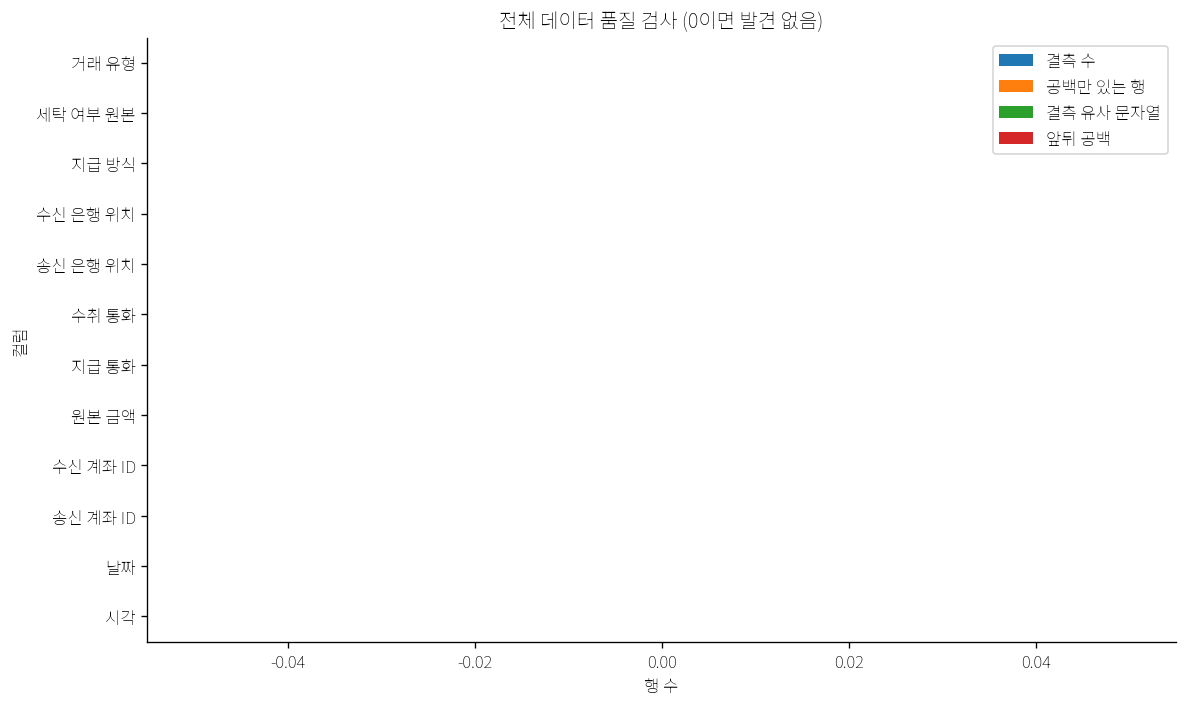

In [6]:
# 3-2. 품질 검사 시각화
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
quality.set_index('column')[['nulls','blank','null_like','outer_spaces']].plot.barh(figsize=(10,6))
plt.xlabel('행 수')
plt.title('전체 데이터 품질 검사 (0이면 발견 없음)')
그림저장('01_quality')

## 4. 변환 오류·금액 부호·계좌 형식 및 기본 통계
`try_*` 변환에 실패한 값은 NULL이 되므로 별도로 집계합니다. 비유한 금액(무한대 등)도 검사합니다. 선행 0은 ID에서 보존해야 하는 값이지 자동 수정 대상이 아닙니다.

### 4-1. 전체 규모·관측 기간·변환 오류 표

rows와 positives/negatives는 거래 수입니다. invalid_*는 변환 또는 라벨 검사 실패, negative_amount/zero_amount는 금액 부호 검사 결과입니다.

In [7]:
# 4-1. 전체 규모·관측 기간·변환 오류 표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
summary = 조회("""SELECT count(*) AS rows, min(ts) AS first_timestamp, max(ts) AS last_timestamp,
    sum(y)::BIGINT AS positives, count(*) FILTER(WHERE y=0) AS negatives,
    count(*) FILTER(WHERE ts IS NULL) AS invalid_datetime,
    count(*) FILTER(WHERE amount_num IS NULL OR NOT isfinite(amount_num)) AS invalid_amount,
    count(*) FILTER(WHERE y IS NULL) AS invalid_label,
    count(*) FILTER(WHERE amount_num<0) AS negative_amount,
    count(*) FILTER(WHERE amount_num=0) AS zero_amount,
    count(*) FILTER(WHERE Sender_account=Receiver_account) AS self_transfers
    FROM tx""", 'summary')
표보기(summary.T.rename(columns={0:'value'}))

,값
전체 거래 수,9504852
첫 거래 일시,2022-10-07 10:35:19
마지막 거래 일시,2023-08-23 10:57:12
양성 거래 수,9873
정상 거래 수,9494979
날짜·시간 변환 실패,0
금액 변환 실패·비유한값,0
비정상 정답,0
음수 금액,0
0원 거래,0


### 4-2. 송신·수신 계좌 ID 형식 표

non_digits는 숫자 외 문자 포함 ID의 등장 행 수, leading_zero는 선행 0이 있는 등장 행 수, unique_ids는 역할별 고유 ID 수입니다.

In [8]:
# 4-2. 송신·수신 계좌 ID 형식 표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
ids = 조회("""SELECT 'sender' AS role,
    count(*) FILTER(WHERE NOT regexp_full_match(Sender_account,'[0-9]+')) AS non_digits,
    count(*) FILTER(WHERE starts_with(Sender_account,'0')) AS leading_zero,
    count(DISTINCT Sender_account) AS unique_ids FROM tx
    UNION ALL SELECT 'receiver',
    count(*) FILTER(WHERE NOT regexp_full_match(Receiver_account,'[0-9]+')),
    count(*) FILTER(WHERE starts_with(Receiver_account,'0')),
    count(DISTINCT Receiver_account) FROM tx""", 'id_quality')
표보기(ids)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,역할,숫자 외 문자 포함 행,선행 0이 있는 행,고유 계좌 ID 수
0,송신,0,0,292715
1,수신,0,0,652266


## 5. 클래스 불균형
정상·양성의 거래 수와 전체 대비 비율을 함께 봅니다. 양성이 적으면 정확도만으로 모델을 판단하기 어렵습니다. 아래 그래프의 왼쪽은 로그 축, 오른쪽은 비율 축입니다.

### 5-1. 정상·양성 건수와 비율 표

transactions는 클래스별 거래 수, percent는 전체 거래 대비 비율입니다.

In [9]:
# 5-1. 정상·양성 건수와 비율 표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
labels = 조회('SELECT y,count(*) AS transactions FROM tx GROUP BY y ORDER BY y', 'labels')
labels['percent'] = 100 * labels.transactions / N
표보기(labels)

,정답(0 정상·1 양성),거래 수,전체 대비 비율(%)
0,0,9494979,99.896127
1,1,9873,0.103873


### 5-2. 클래스 불균형 그래프

왼쪽은 거래 수의 로그 축, 오른쪽은 전체 대비 비율입니다. 축의 단위가 다름에 유의하세요.

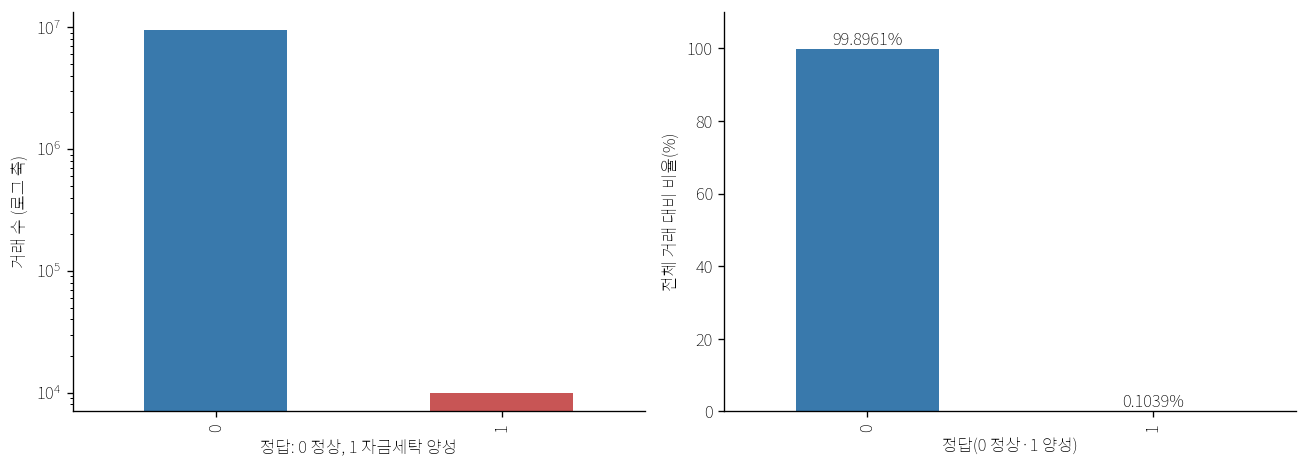

In [10]:
# 5-2. 클래스 불균형 그래프
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
fig, ax = plt.subplots(1,2,figsize=(11,4))
labels.plot.bar(x='y',y='transactions',logy=True,legend=False,ax=ax[0],color=['#3979ac','#c85555'])
ax[0].set_ylabel('거래 수 (로그 축)')
ax[0].set_xlabel('정답: 0 정상, 1 자금세탁 양성')
labels.plot.bar(x='y',y='percent',legend=False,ax=ax[1],color=['#3979ac','#c85555'])
for i,v in enumerate(labels.percent): ax[1].text(i,v+1,f'{v:.4f}%',ha='center')
ax[1].set_ylim(0,110)
ax[1].set_ylabel('전체 거래 대비 비율(%)')
그림저장('02_class_balance')

### 5-3. 양성 비율 요약

전체 거래를 분모로 계산한 양성 비율을 문장으로 확인합니다.

In [11]:
# 5-3. 양성 비율 요약
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
POS = int(summary.positives.iloc[0])
표보기(Markdown(f'**양성 {POS:,}건 / 전체 {N:,}건 = {100*POS/N:.4f}%**'))

**양성 9,873건 / 전체 9,504,852건 = 0.1039%**

## 6. 일별·월별·요일·시간대 분포
거래량과 양성 비율은 서로 다른 질문입니다. 양성 건수 증가가 거래량 증가 때문인지, 비율 자체가 변했는지 함께 봅니다. 기간 첫날·마지막 날의 관측 시간이 하루를 채우는지 확인하되, 불완전한 날짜라고 임의 삭제하지 않습니다.

누락 날짜는 집계에 행이 없을 수 있으므로 전체 날짜 달력과 비교합니다. 차트는 실제 관측일을 표시합니다.

### 6-1. 기간 경계일의 거래 범위

관측일 수와 거래 없는 날짜 수를 계산하고 첫날·마지막 날의 첫/마지막 거래 시각을 표시합니다.

In [12]:
# 6-1. 기간 경계일의 거래 범위
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
daily = 조회("""SELECT cast(ts AS DATE) AS day,count(*) AS transactions,sum(y)::BIGINT AS positives,
    100.0*sum(y)/count(*) AS positive_pct,min(ts) AS first_time,max(ts) AS last_time
    FROM tx WHERE ts IS NOT NULL GROUP BY 1 ORDER BY 1""", 'daily')
daily.day = pd.to_datetime(daily.day)
missing_days = pd.date_range(daily.day.min(),daily.day.max()).difference(daily.day)
print('관측일:',len(daily),'거래 없는 날짜 수:',len(missing_days))
표보기(daily.iloc[[0,-1]])

관측일: 321 거래 없는 날짜 수: 0


,날짜,거래 수,양성 거래 수,양성 비율(%),당일 첫 거래,당일 마지막 거래
0,2022-10-07,20892,27,0.129236,2022-10-07 10:35:19,2022-10-07 23:59:55
320,2023-08-23,8400,7,0.083333,2023-08-23 00:00:01,2023-08-23 10:57:12


### 6-2. 월별 거래·양성 집계표

월별 건수와 양성 비율을 함께 확인합니다. 월별 일수가 다르므로 건수만으로 빈도를 비교하지 않습니다.

In [13]:
# 6-2. 월별 거래·양성 집계표
# groupby: 같은 범주끼리 묶습니다. sum=합계, count/size=개수, nunique=고유값 수입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
monthly = daily.assign(month=daily.day.dt.strftime('%Y-%m')).groupby('month')[['transactions','positives']].sum()
monthly['positive_pct'] = 100*monthly.positives/monthly.transactions
표보기(monthly)

,거래 수,양성 거래 수,양성 비율(%)
월,,,
2022-10,708654,694,0.097932
2022-11,897621,794,0.088456
2022-12,900341,907,0.100740
2023-01,908320,940,0.103488
2023-02,904806,946,0.104553
2023-03,908562,927,0.102029
2023-04,902883,962,0.106548
2023-05,917601,866,0.094377
2023-06,897243,1024,0.114127


### 6-3. 일별 추이 그래프

위부터 전체 거래량, 양성 거래 수, 양성 비율입니다. 동일 날짜 축으로 비교하세요.

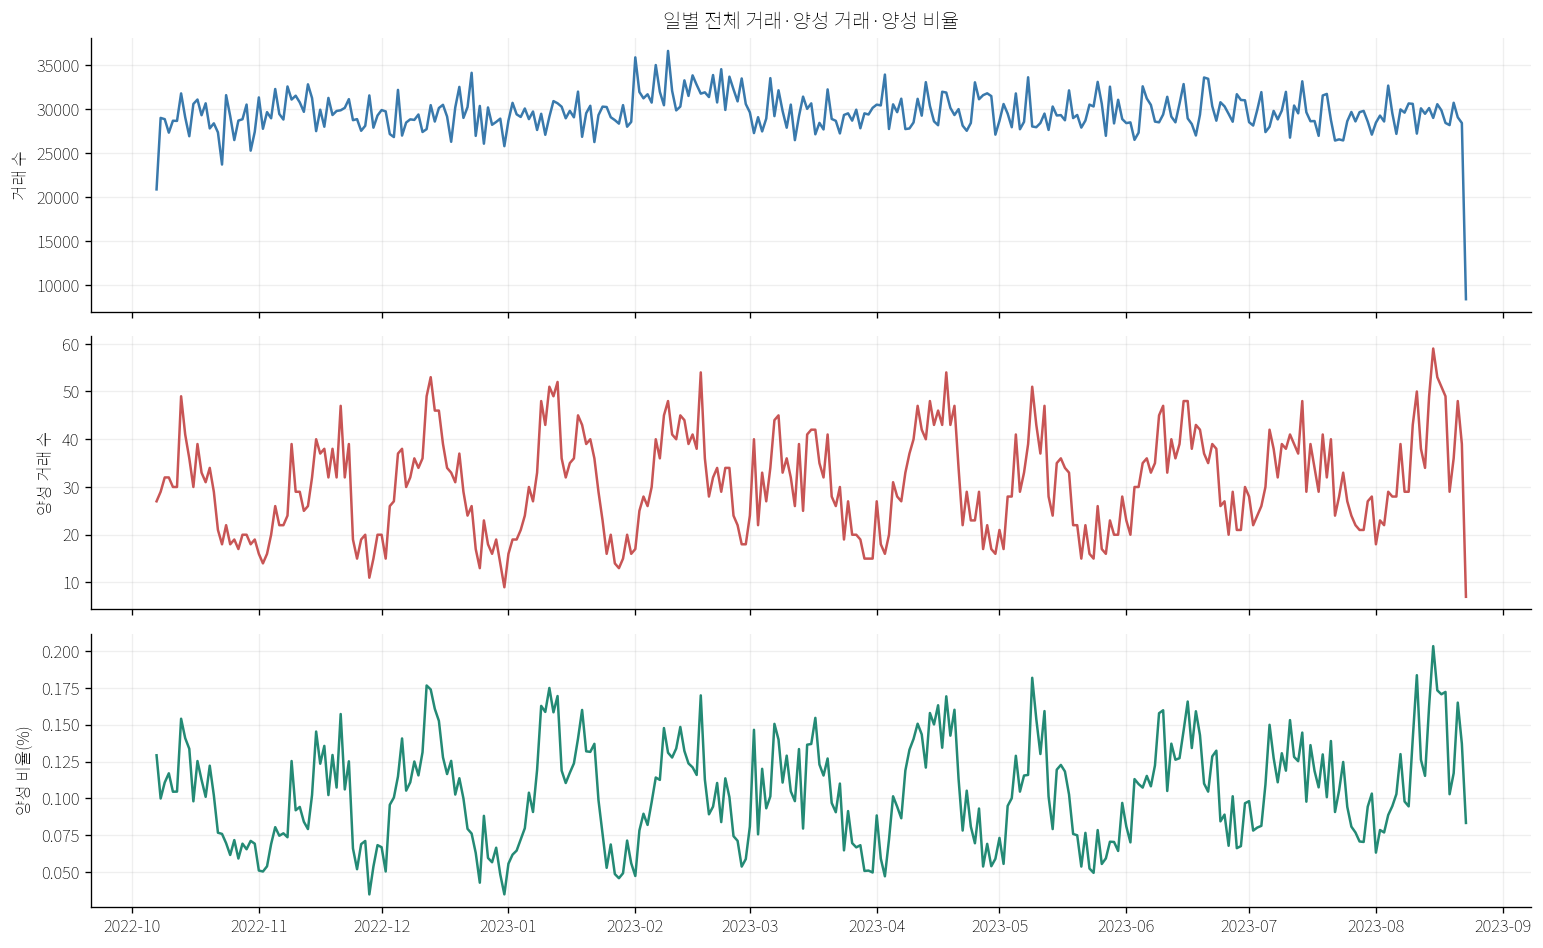

In [14]:
# 6-3. 일별 추이 그래프
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
monthly.to_csv(OUTPUT/'monthly.csv')
fig,ax=plt.subplots(3,1,figsize=(13,8),sharex=True)
for a,col,color in zip(ax,['transactions','positives','positive_pct'],['#3979ac','#c85555','#248a75']):
    a.plot(daily.day,daily[col],color=color); a.set_ylabel(col); a.grid(alpha=.2)
ax[0].set_title('일별 전체 거래·양성 거래·양성 비율')
그림저장('03_daily')

### 6-4. 시간대·요일별 양성 비율 그래프

시간대와 요일별 전체 거래를 각각 분모로 사용합니다. ISO 요일 1은 월요일입니다.

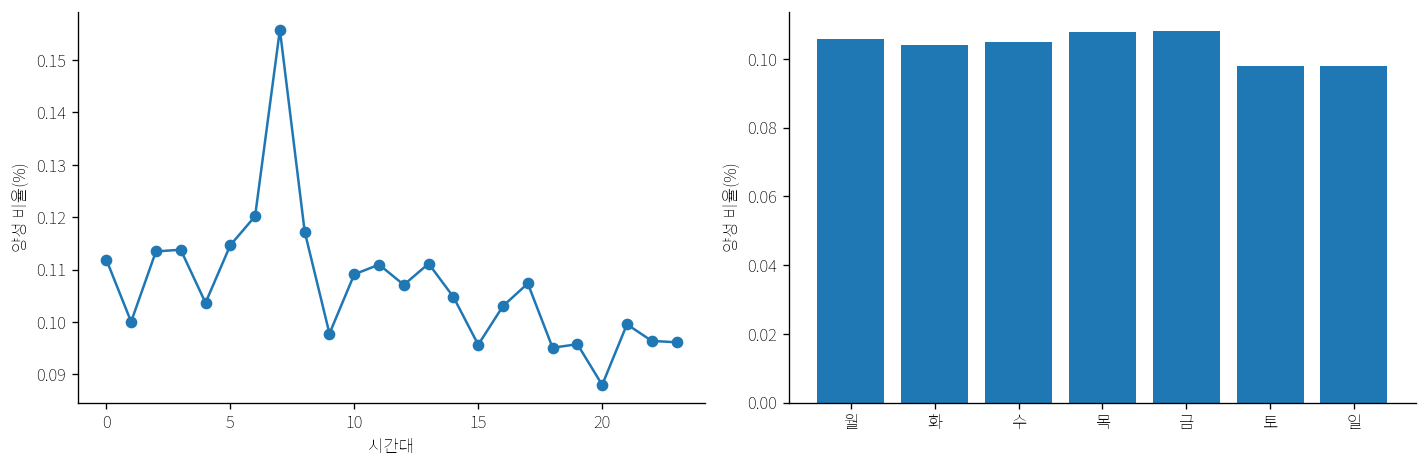

In [15]:
# 6-4. 시간대·요일별 양성 비율 그래프
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
hourly=조회("""SELECT hour(ts) AS hour,count(*) AS transactions,sum(y)::BIGINT AS positives,
    100.0*sum(y)/count(*) AS positive_pct FROM tx WHERE ts IS NOT NULL GROUP BY 1 ORDER BY 1""",'hourly')
weekday=조회("""SELECT isodow(ts) AS weekday,count(*) AS transactions,sum(y)::BIGINT AS positives,
    100.0*sum(y)/count(*) AS positive_pct FROM tx WHERE ts IS NOT NULL GROUP BY 1 ORDER BY 1""",'weekday')
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(hourly.hour,hourly.positive_pct,marker='o')
ax[0].set_xlabel('시간대')
ax[0].set_ylabel('양성 비율(%)')
ax[1].bar(weekday.weekday,weekday.positive_pct)
ax[1].set_xticks(range(1,8),['월','화','수','목','금','토','일'])
ax[1].set_ylabel('양성 비율(%)')
그림저장('04_hour_weekday')

## 7. 거래 유형과 이진 라벨의 관계
`Laundering_type`별 정상·양성 건수를 교차 집계합니다. 양성 유형 막대는 **거래 건수**이며 독립적인 사건·작전 수가 아닙니다. SAML-D 원본에는 별도의 작전 ID가 없으므로 유형이 같다고 동일 사건으로 묶지 않습니다.

유형별 라벨이 하나로 결정된다면 `Laundering_type`을 입력 피처로 넣는 것은 직접적인 정답 누수입니다. 그래프가 보여주는 관계는 관측된 연관성이며 인과관계가 아닙니다.

### 7-1. 유형 × 이진 라벨 교차표

행은 유형, 열 0/1은 정상/양성입니다. 각 칸은 거래 건수이며 사건 개수가 아닙니다.

In [16]:
# 7-1. 유형 × 이진 라벨 교차표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# pivot/pivot_table: 행·열 범주별 교차표를 만듭니다. fillna(0)은 없는 조합의 집계값을 0으로 표시합니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
types=조회("""SELECT Laundering_type,y,count(*) AS transactions FROM tx GROUP BY 1,2 ORDER BY 1,2""",'type_label')
cross=types.pivot_table(index='Laundering_type',columns='y',values='transactions',aggfunc='sum',fill_value=0)
표보기(cross)

정답(0 정상·1 양성),정상(0),양성(1)
거래 유형,,
Behavioural_Change_1,0,394
Behavioural_Change_2,0,345
Bipartite,0,383
Cash_Withdrawal,0,1334
Cycle,0,382
Deposit-Send,0,945
Fan_In,0,364
Fan_Out,0,237
Gather-Scatter,0,354


### 7-2. 정상·양성 유형별 거래 수 그래프

정상과 양성을 패널로 나눠 표시합니다. 표에서 계산한 유형별 라벨 혼재 여부도 출력합니다.

정상·양성 라벨이 혼재한 유형 수: 0


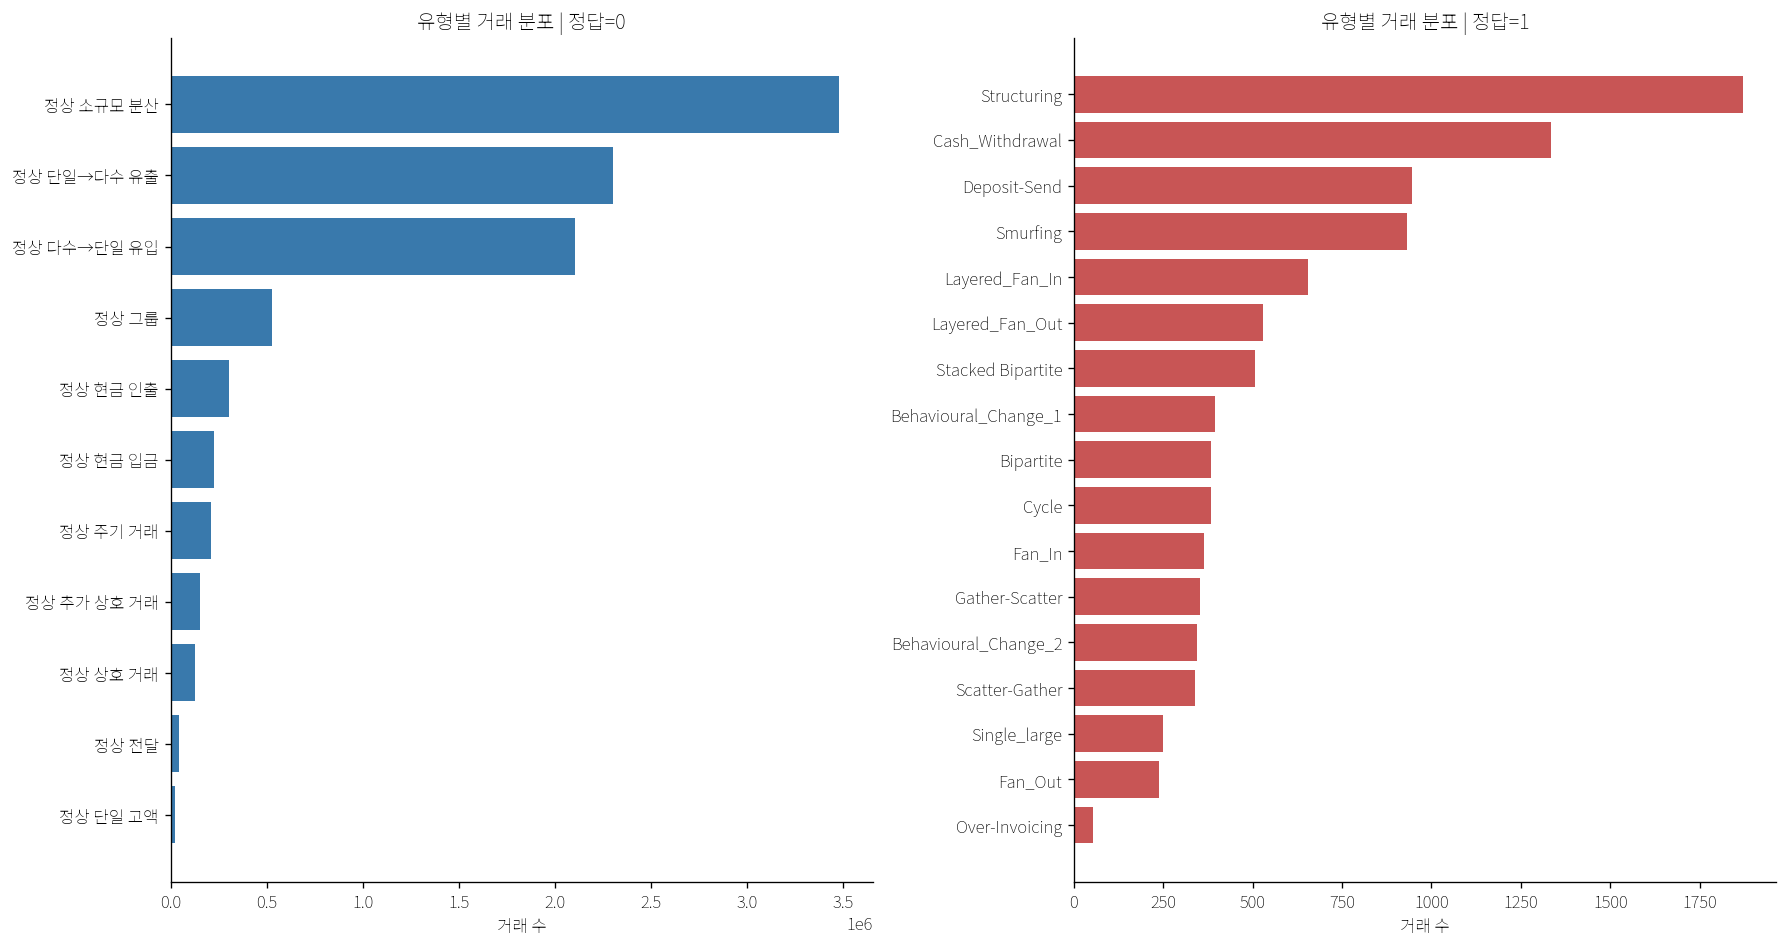

In [17]:
# 7-2. 정상·양성 유형별 거래 수 그래프
# groupby: 같은 범주끼리 묶습니다. sum=합계, count/size=개수, nunique=고유값 수입니다.
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
conflicts=int((types.groupby('Laundering_type').y.nunique()>1).sum())
print('정상·양성 라벨이 혼재한 유형 수:',conflicts)
fig,ax=plt.subplots(1,2,figsize=(15,8))
for a,label in zip(ax,[0,1]):
    q=types[types.y==label].sort_values('transactions')
    a.barh(q.Laundering_type,q.transactions,color='#3979ac' if label==0 else '#c85555')
    a.set_title(f'유형별 거래 분포 | 정답={label}'); a.set_xlabel('거래 수')
그림저장('05_type_distribution')

## 8. 유형별 시간적 편중
월별 양성 유형 건수를 먼저 집계하고, 각 월의 전체 양성 대비 구성비를 히트맵으로 표시합니다. 비율이 비슷해도 원래 건수는 크게 다를 수 있으므로 집계표를 함께 확인합니다.

### 8-1. 월별 양성 유형 건수 표

각 칸은 해당 월·유형에 속한 양성 거래 수입니다. 0은 해당 조합이 관측되지 않았다는 뜻입니다.

In [18]:
# 8-1. 월별 양성 유형 건수 표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# pivot/pivot_table: 행·열 범주별 교차표를 만듭니다. fillna(0)은 없는 조합의 집계값을 0으로 표시합니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
monthly_type=조회("""SELECT strftime(ts,'%Y-%m') AS month,Laundering_type,count(*) AS transactions
    FROM tx WHERE y=1 AND ts IS NOT NULL GROUP BY 1,2 ORDER BY 1,2""",'monthly_positive_type')
counts=monthly_type.pivot(index='Laundering_type',columns='month',values='transactions').fillna(0)
shares=counts.div(counts.sum(axis=0),axis=1)*100
표보기(counts.astype(int))

월,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08
거래 유형,,,,,,,,,,,
Behavioural_Change_1,48,21,36,32,17,26,64,24,57,53,16
Behavioural_Change_2,20,22,28,31,30,13,44,33,57,45,22
Bipartite,14,18,64,40,41,49,59,43,29,18,8
Cash_Withdrawal,74,138,118,147,106,145,81,125,151,110,139
Cycle,15,1,54,46,59,44,24,58,32,41,8
Deposit-Send,54,90,69,85,96,104,105,86,81,107,68
Fan_In,34,26,54,13,12,23,65,53,45,11,28
Fan_Out,10,13,29,3,19,10,8,22,61,16,46
Gather-Scatter,22,47,34,12,42,33,33,8,38,44,41


### 8-2. 월별 양성 유형 구성비 히트맵

각 월의 전체 양성을 100%로 정규화합니다. 앞의 건수 표와 함께 해석하세요.

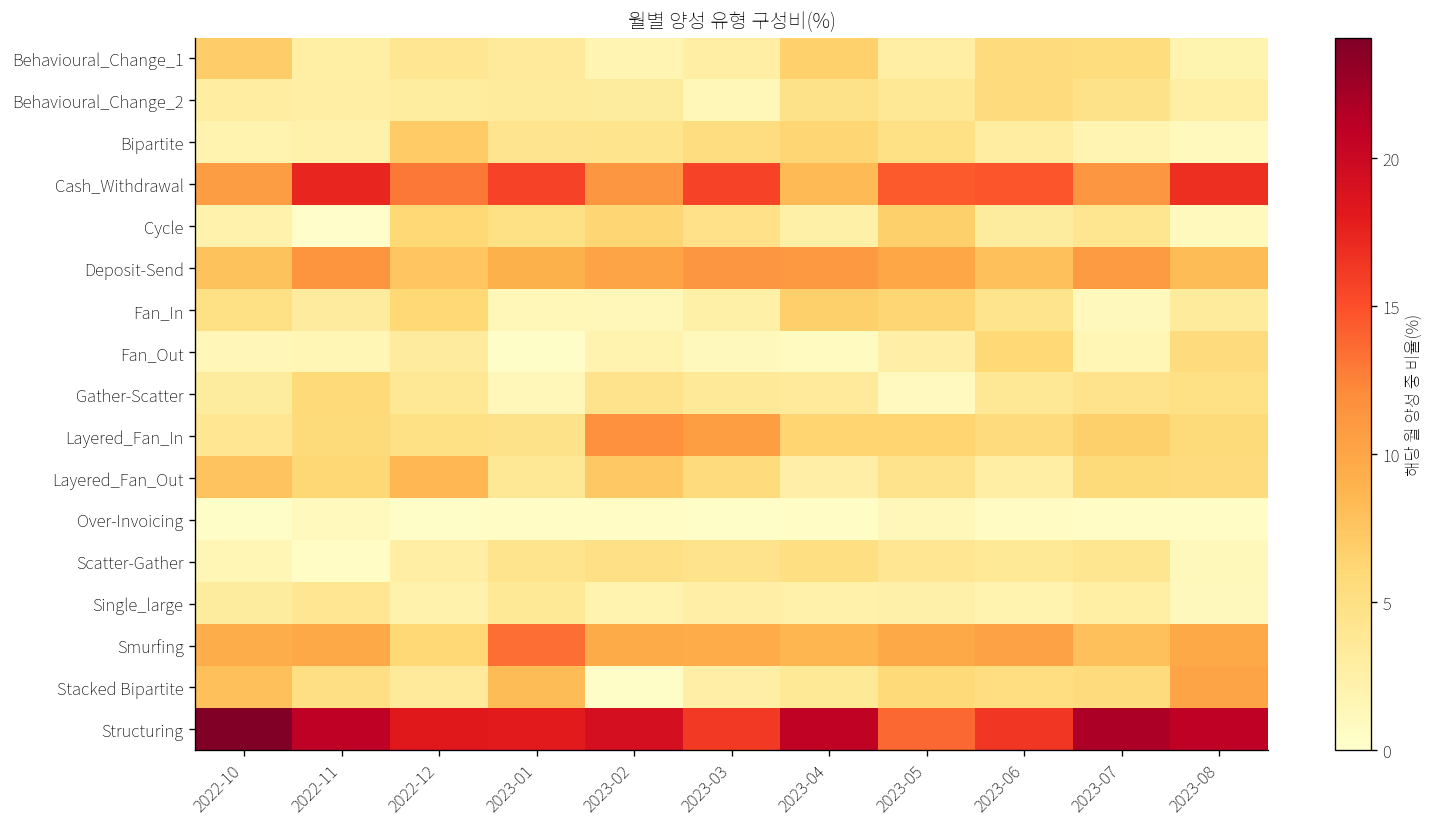

In [19]:
# 8-2. 월별 양성 유형 구성비 히트맵
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
fig,ax=plt.subplots(figsize=(13,7))
im=ax.imshow(shares.to_numpy(),aspect='auto',cmap='YlOrRd',vmin=0)
ax.set_xticks(range(len(shares.columns)),shares.columns,rotation=45,ha='right')
ax.set_yticks(range(len(shares.index)),shares.index)
ax.set_title('월별 양성 유형 구성비(%)')
fig.colorbar(im,ax=ax,label='해당 월 양성 중 비율(%)')
그림저장('06_monthly_types')

## 9. 통화·지급 방식의 거래량과 양성 비율
빈도가 높은 범주와 양성 비율이 높은 범주를 구분합니다. 표에는 분모인 거래 수와 양성 수도 함께 출력합니다. 적은 표본의 높은 비율을 곧바로 위험 점수로 해석하면 안 됩니다.

### 9-1. 지급 통화별 거래·양성 집계표

category는 범주, transactions는 분모인 거래 수, positives는 양성 수, positive_pct는 범주 내 양성 비율입니다.

In [20]:
# 9-1. 지급 통화별 거래·양성 집계표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
category_tables={}
column = 'Payment_currency'
t=조회(f"SELECT {ident(column)} AS category,count(*) AS transactions,sum(y)::BIGINT AS positives,100.0*sum(y)/count(*) AS positive_pct FROM tx GROUP BY 1 ORDER BY transactions DESC",column)
category_tables[column]=t
표보기(t)

,범주,거래 수,양성 거래 수,양성 비율(%)
0,영국 파운드,9099293,8830,0.097041
1,유로,117164,260,0.221911
2,튀르키예 리라,27996,73,0.260752
3,스위스 프랑,27492,82,0.298269
4,디르함,27263,89,0.326450
5,파키스탄 루피,27196,62,0.227975
6,나이지리아 나이라,27143,62,0.228420
7,미국 달러,26061,60,0.230229
8,일본 엔,25562,65,0.254284
9,모로코 디르함,25395,90,0.354400


### 9-2. 지급 통화별 거래량·양성 비율 그래프

왼쪽은 거래 건수(로그 축), 오른쪽은 양성 비율입니다. 거래량이 적은 범주는 비율과 분모를 함께 확인하세요.

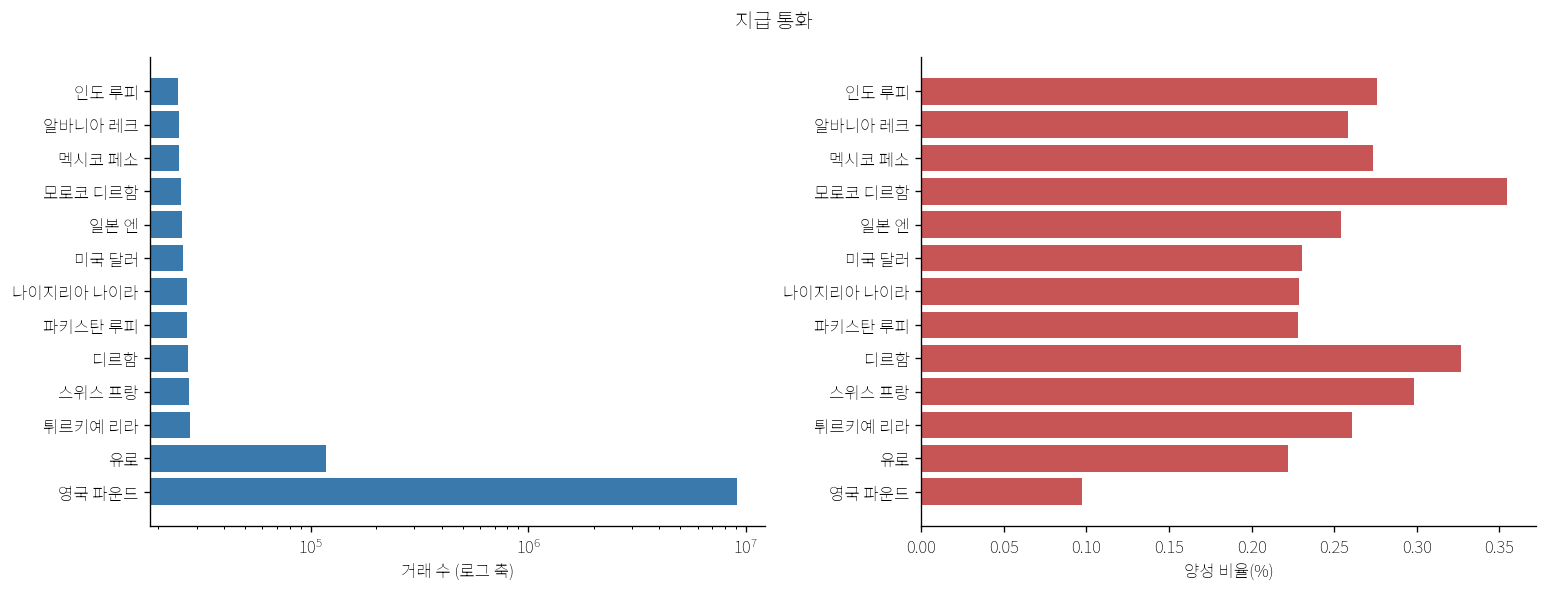

In [21]:
# 9-2. 지급 통화별 거래량·양성 비율 그래프
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].barh(t.category,t.transactions,color='#3979ac')
ax[0].set_xscale('log')
ax[0].set_xlabel('거래 수 (로그 축)')
ax[1].barh(t.category,t.positive_pct,color='#c85555')
ax[1].set_xlabel('양성 비율(%)')
fig.suptitle(column)
그림저장('07_'+column)

### 9-3. 수취 통화별 거래·양성 집계표

category는 범주, transactions는 분모인 거래 수, positives는 양성 수, positive_pct는 범주 내 양성 비율입니다.

In [22]:
# 9-3. 수취 통화별 거래·양성 집계표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
column = 'Received_currency'
t=조회(f"SELECT {ident(column)} AS category,count(*) AS transactions,sum(y)::BIGINT AS positives,100.0*sum(y)/count(*) AS positive_pct FROM tx GROUP BY 1 ORDER BY transactions DESC",column)
category_tables[column]=t
표보기(t)

,범주,거래 수,양성 거래 수,양성 비율(%)
0,영국 파운드,8783655,6919,0.078771
1,유로,231911,716,0.308739
2,파키스탄 루피,45993,204,0.443546
3,일본 엔,45814,118,0.257563
4,모로코 디르함,45748,285,0.622978
5,알바니아 레크,45736,262,0.572853
6,멕시코 페소,45255,235,0.519280
7,나이지리아 나이라,45046,288,0.639346
8,인도 루피,43757,172,0.393080
9,미국 달러,43664,118,0.270246


### 9-4. 수취 통화별 거래량·양성 비율 그래프

왼쪽은 거래 건수(로그 축), 오른쪽은 양성 비율입니다. 거래량이 적은 범주는 비율과 분모를 함께 확인하세요.

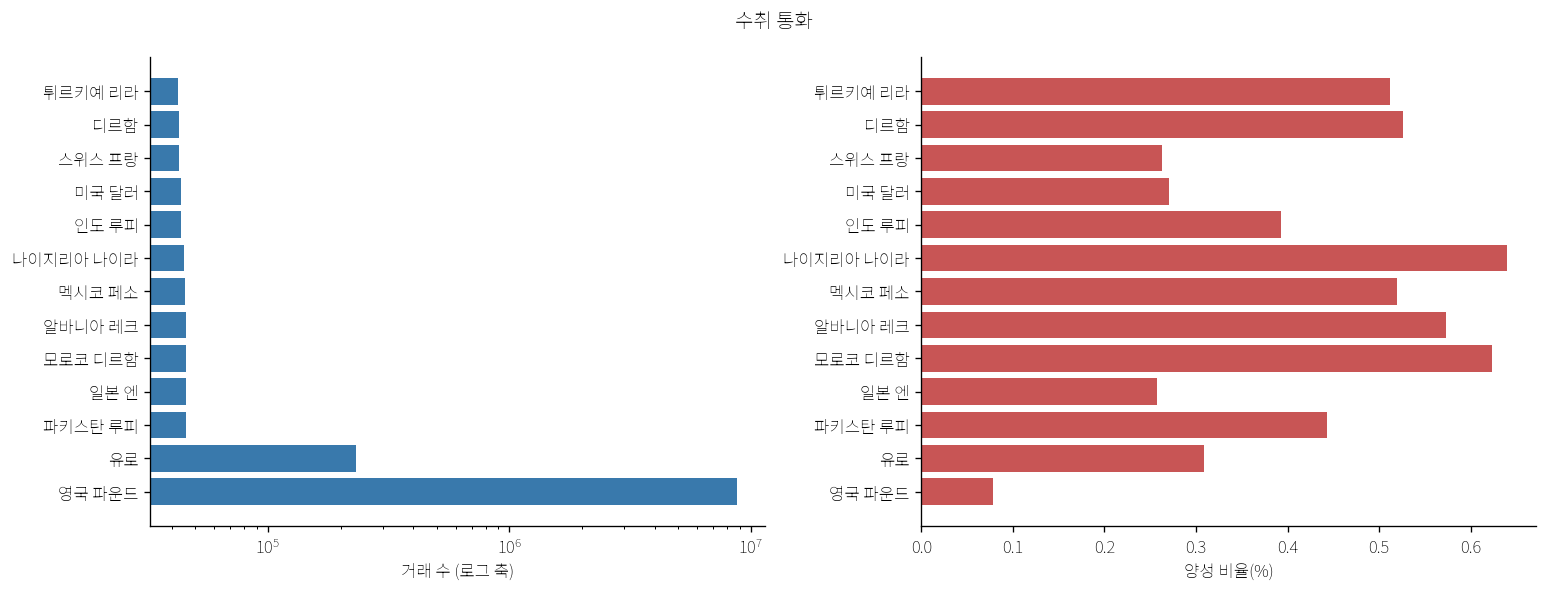

In [23]:
# 9-4. 수취 통화별 거래량·양성 비율 그래프
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].barh(t.category,t.transactions,color='#3979ac')
ax[0].set_xscale('log')
ax[0].set_xlabel('거래 수 (로그 축)')
ax[1].barh(t.category,t.positive_pct,color='#c85555')
ax[1].set_xlabel('양성 비율(%)')
fig.suptitle(column)
그림저장('07_'+column)

### 9-5. 지급 방식별 거래·양성 집계표

category는 범주, transactions는 분모인 거래 수, positives는 양성 수, positive_pct는 범주 내 양성 비율입니다.

In [24]:
# 9-5. 지급 방식별 거래·양성 집계표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
column = 'Payment_type'
t=조회(f"SELECT {ident(column)} AS category,count(*) AS transactions,sum(y)::BIGINT AS positives,100.0*sum(y)/count(*) AS positive_pct FROM tx GROUP BY 1 ORDER BY transactions DESC",column)
category_tables[column]=t
표보기(t)

,범주,거래 수,양성 거래 수,양성 비율(%)
0,신용카드,2012909,1136,0.056436
1,직불카드,2012103,1124,0.055862
2,수표,2011419,1087,0.054041
3,자동이체(ACH),2008807,1159,0.057696
4,국경 간 거래,933931,2628,0.281391
5,현금 인출,300477,1334,0.443961
6,현금 입금,225206,1405,0.623873


### 9-6. 지급 방식별 거래량·양성 비율 그래프

왼쪽은 거래 건수(로그 축), 오른쪽은 양성 비율입니다. 거래량이 적은 범주는 비율과 분모를 함께 확인하세요.

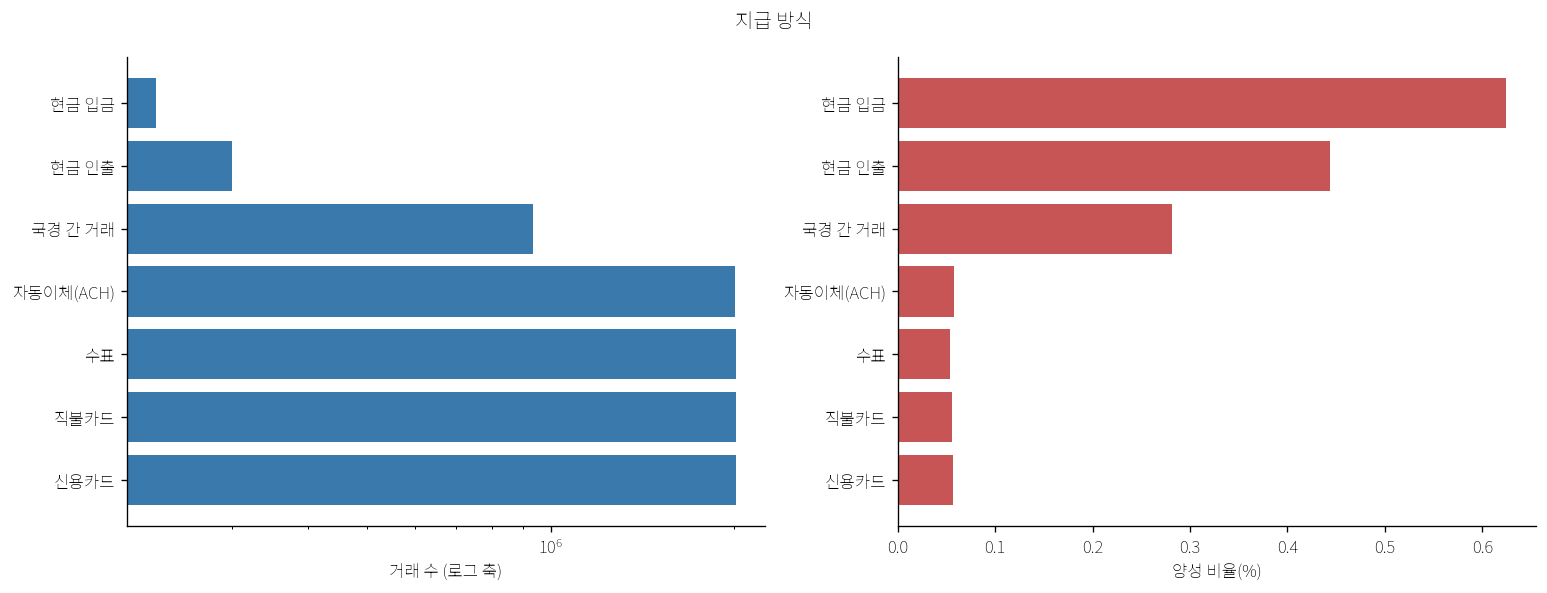

In [25]:
# 9-6. 지급 방식별 거래량·양성 비율 그래프
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].barh(t.category,t.transactions,color='#3979ac')
ax[0].set_xscale('log')
ax[0].set_xlabel('거래 수 (로그 축)')
ax[1].barh(t.category,t.positive_pct,color='#c85555')
ax[1].set_xlabel('양성 비율(%)')
fig.suptitle(column)
그림저장('07_'+column)

## 10. 금액 분포 — 통화별 전체 분위수와 표본 히스토그램
서로 다른 통화의 원금액을 하나의 분포로 합쳐 평균을 비교하지 않습니다. 여기서는 `Payment_currency`로 조건을 나눕니다. `Amount`가 어느 통화 기준인지는 원본 값만으로 확정하지 않으며 별도 명세 확인 대상입니다.

분위수·극값·평균은 **전체 데이터**에서 구합니다. 히스토그램만 행 ID 해시로 약 1%를 선택한 재현 가능한 표본입니다. 드문 양성은 전량 사용하고, 정상은 표본을 사용합니다. 밀도 곡선의 면적은 클래스별 1이므로 클래스 비율을 나타내지 않습니다. `log10(1+금액)`은 시각화용이며 학습 변환을 확정한 것이 아닙니다.

### 10-1. 통화·라벨별 금액 분위수 표

전체 유효 금액에서 분위수를 계산합니다. p01~p999는 1~99.9백분위수이며 minimum/maximum은 극값, mean은 평균입니다.

In [26]:
# 10-1. 통화·라벨별 금액 분위수 표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
amount=조회("""SELECT Payment_currency,y,count(*) AS transactions,min(amount_num) AS minimum,
    quantile_cont(amount_num,.01) AS p01,quantile_cont(amount_num,.25) AS p25,
    median(amount_num) AS median,quantile_cont(amount_num,.75) AS p75,
    quantile_cont(amount_num,.95) AS p95,quantile_cont(amount_num,.99) AS p99,
    quantile_cont(amount_num,.999) AS p999,max(amount_num) AS maximum,avg(amount_num) AS mean
    FROM tx WHERE isfinite(amount_num) GROUP BY 1,2 ORDER BY 1,2""",'amount_quantiles')
표보기(amount)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,지급 통화,정답(0 정상·1 양성),거래 수,최솟값,1백분위수,25백분위수,중앙값,75백분위수,95백분위수,99백분위수,99.9백분위수,최댓값,평균
0,알바니아 레크,0,24714,18.820000,119.28420,3903.9350,7154.855000,11633.075000,23832.511000,4.892228e+04,2.383217e+05,9.358207e+05,9615.598072
1,알바니아 레크,1,64,2800.750000,2855.14420,4749.3450,6506.990000,11294.895000,34732.939205,5.211695e+04,7.332685e+04,7.568350e+04,10711.803623
2,디르함,0,27174,17.170000,159.78330,4593.8375,7161.275000,11694.162500,23679.271500,4.946257e+04,2.515641e+05,9.561930e+05,9907.217582
3,디르함,1,89,2259.180000,2716.59520,4245.3800,6289.900000,9798.310000,37250.534444,5.873015e+04,6.245409e+04,6.286786e+04,10902.371375
4,유로,0,116904,9.150000,172.92330,4972.8300,7642.735000,12156.180000,25429.531000,5.360474e+04,2.962216e+05,9.956759e+05,10523.269269
5,유로,1,260,1250.410000,2311.90710,4470.5075,6497.501465,11887.837500,66535.648256,1.545572e+05,2.822789e+05,2.941676e+05,16758.714386
6,인도 루피,0,24589,13.410000,161.41280,4646.0900,7323.480000,11936.550000,24032.400000,5.599323e+04,3.412867e+05,9.856780e+05,10217.446434
7,인도 루피,1,68,2618.800000,2631.46300,4088.4550,6020.887746,9534.081785,23943.533390,6.660685e+04,6.753256e+04,6.763542e+04,9736.177476
8,멕시코 페소,0,24784,5.900000,122.57540,4632.9925,7395.620000,11741.607500,25546.058000,5.047320e+04,2.707376e+05,9.920455e+05,10212.466525
9,멕시코 페소,1,68,2302.400000,2539.04400,5009.0250,6709.145000,11178.060000,41611.135350,1.380758e+06,1.874038e+06,1.928847e+06,54143.330654


### 10-2. 통화별 금액 히스토그램

정상 약 1% 표본과 양성 전량으로 표시합니다. 시각화 표본 수를 출력하며, 밀도는 클래스별로 정규화됩니다.

금액 시각화용 행 수: 105743 | 정상 표본: 95870 | 전체 양성: 9873


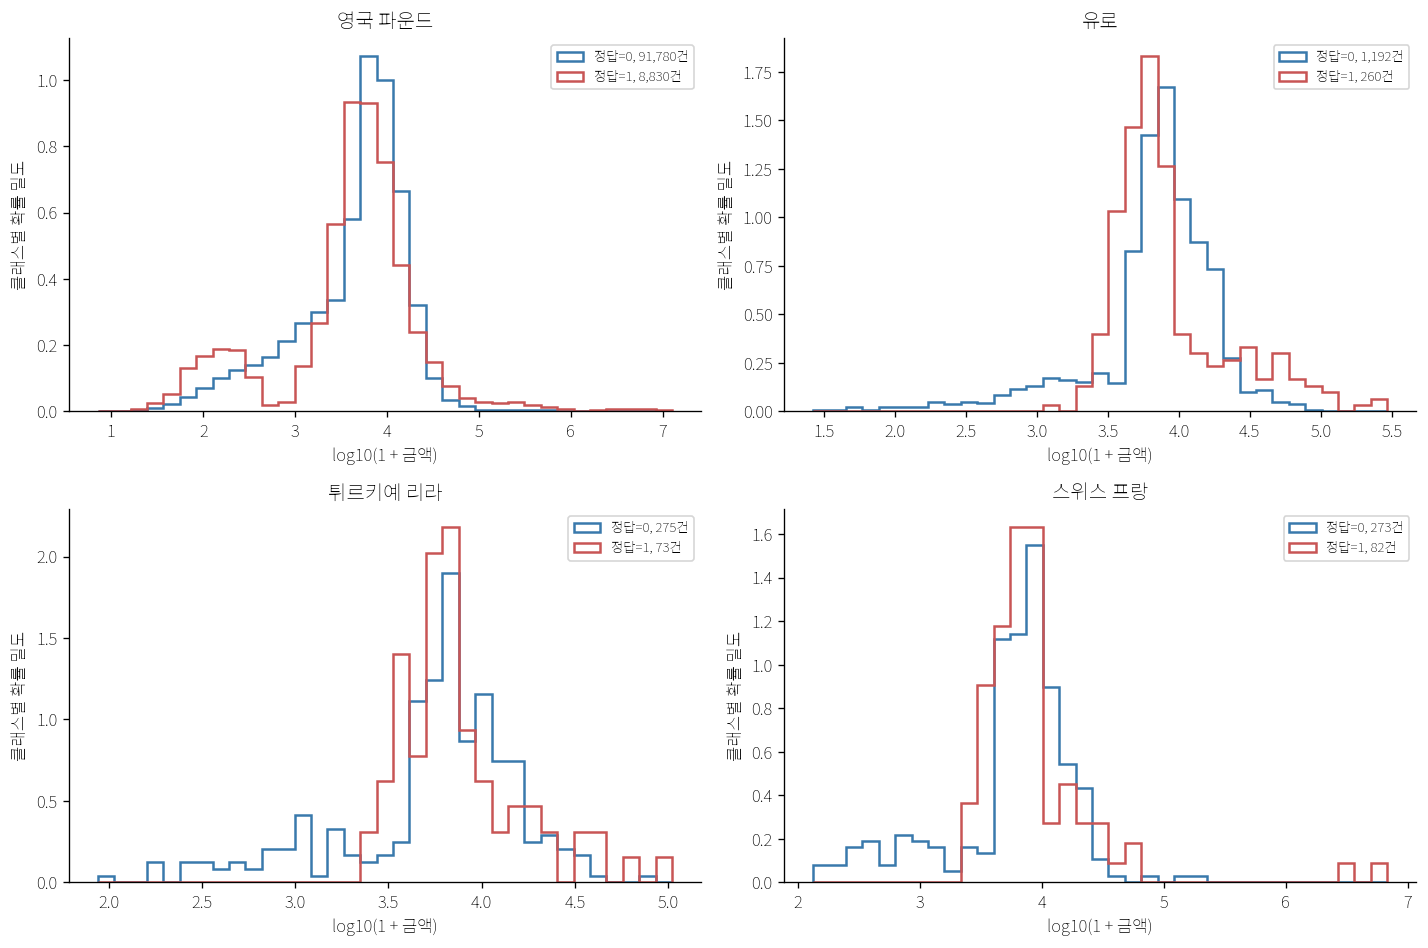

In [27]:
# 10-2. 통화별 금액 히스토그램
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
sample=조회("""SELECT Payment_currency,amount_num,y FROM tx
    WHERE isfinite(amount_num) AND amount_num>=0 AND (y=1 OR hash(row_id)%100=0)""")
print('금액 시각화용 행 수:',len(sample),'| 정상 표본:',int((sample.y==0).sum()),'| 전체 양성:',int((sample.y==1).sum()))
top=category_tables['Payment_currency'].category.head(4).tolist()
fig,axes=plt.subplots(2,2,figsize=(12,8))
for ax,cur in zip(axes.flat,top):
    q=sample[sample.Payment_currency==cur]
    edges=np.histogram_bin_edges(np.log10(1+q.amount_num),bins=35)
    for label,color in [(0,'#3979ac'),(1,'#c85555')]:
        values=np.log10(1+q.loc[q.y==label,'amount_num'])
        if len(values):ax.hist(values,bins=edges,density=True,histtype='step',linewidth=1.5,color=color,label=f'정답={label}, {len(values):,}건')
    ax.set_title(cur);ax.set_xlabel('log10(1 + 금액)');ax.set_ylabel('클래스별 확률 밀도');ax.legend(fontsize=8)
그림저장('08_amount_histograms')

### 10-3. 통화별 상단 꼬리 집계표

above_upper_iqr는 Q3+1.5×IQR 초과, above_p99는 99백분위수 초과 건수입니다. 극단값이라는 이유로 삭제하지 않습니다.

In [28]:
# 10-3. 통화별 상단 꼬리 집계표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
tails=조회("""WITH q AS (SELECT Payment_currency,quantile_cont(amount_num,.25) AS q1,
    quantile_cont(amount_num,.75) AS q3,quantile_cont(amount_num,.99) AS p99 FROM tx
    WHERE isfinite(amount_num) GROUP BY 1)
    SELECT t.Payment_currency,count(*) AS transactions,
    count(*) FILTER(WHERE amount_num>q3+1.5*(q3-q1)) AS above_upper_iqr,
    count(*) FILTER(WHERE amount_num>p99) AS above_p99,
    count(*) FILTER(WHERE amount_num>p99 AND y=1) AS positives_above_p99
    FROM tx t JOIN q USING(Payment_currency) GROUP BY 1 ORDER BY 1""",'amount_tails')
표보기(tails)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,지급 통화,거래 수,IQR 상단 초과 거래,99백분위수 초과 거래,99백분위수 초과 양성
0,알바니아 레크,24778,1365,248,1
1,디르함,27263,1573,273,3
2,유로,117164,7358,1172,17
3,인도 루피,24657,1367,247,2
4,멕시코 페소,24852,1671,249,3
5,모로코 디르함,25395,1524,254,8
6,나이지리아 나이라,27143,1594,272,0
7,파키스탄 루피,27196,1663,272,1
8,스위스 프랑,27492,1653,275,4
9,튀르키예 리라,27996,1623,280,2


**금액 해석:** IQR 상단·99분위수 초과는 분포상 큰 값이라는 뜻입니다. 오류 또는 세탁이라고 확정하지 않습니다. 이 노트북은 이러한 거래를 삭제하지 않습니다.

## 11. 송수신 통화와 은행 위치의 조합
통화 변경과 은행 위치 변경을 구분합니다. 아래 교차표는 전체 거래 수이며, 큰 범주가 작은 범주를 가리지 않도록 색상에 `log10(1+건수)`를 사용합니다. 위치가 다르다는 이유만으로 불법 거래로 분류하지 않습니다.

### 11-1. 송수신 통화 조합 상위 15개 표

source는 지급 통화, destination은 수취 통화입니다. 전체 조합을 CSV에 저장하고 거래 수 상위 15개를 표시합니다.

In [29]:
# 11-1. 송수신 통화 조합 상위 15개 표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
(name, left, right) = ('currency_pairs', 'Payment_currency', 'Received_currency')
pairs=조회(f'SELECT {ident(left)} AS source,{ident(right)} AS destination,count(*) AS transactions,sum(y)::BIGINT AS positives FROM tx GROUP BY 1,2',name)
표보기(pairs.sort_values('transactions',ascending=False).head(15))

,송신·지급 범주,수신·수취 범주,거래 수,양성 거래 수
86,영국 파운드,영국 파운드,8414112,6171
89,영국 파운드,유로,220504,625
0,유로,영국 파운드,106608,186
98,영국 파운드,파키스탄 루피,43895,187
13,영국 파운드,일본 엔,43517,101
96,영국 파운드,모로코 디르함,43461,261
5,영국 파운드,멕시코 페소,43174,220
90,영국 파운드,알바니아 레크,43040,232
3,영국 파운드,나이지리아 나이라,42696,261
93,영국 파운드,인도 루피,41719,156


### 11-2. 송수신 통화 조합 히트맵

색상은 log10(1+거래 수)입니다. 양성 비율이 아닌 전체 거래량의 조합 분포입니다.

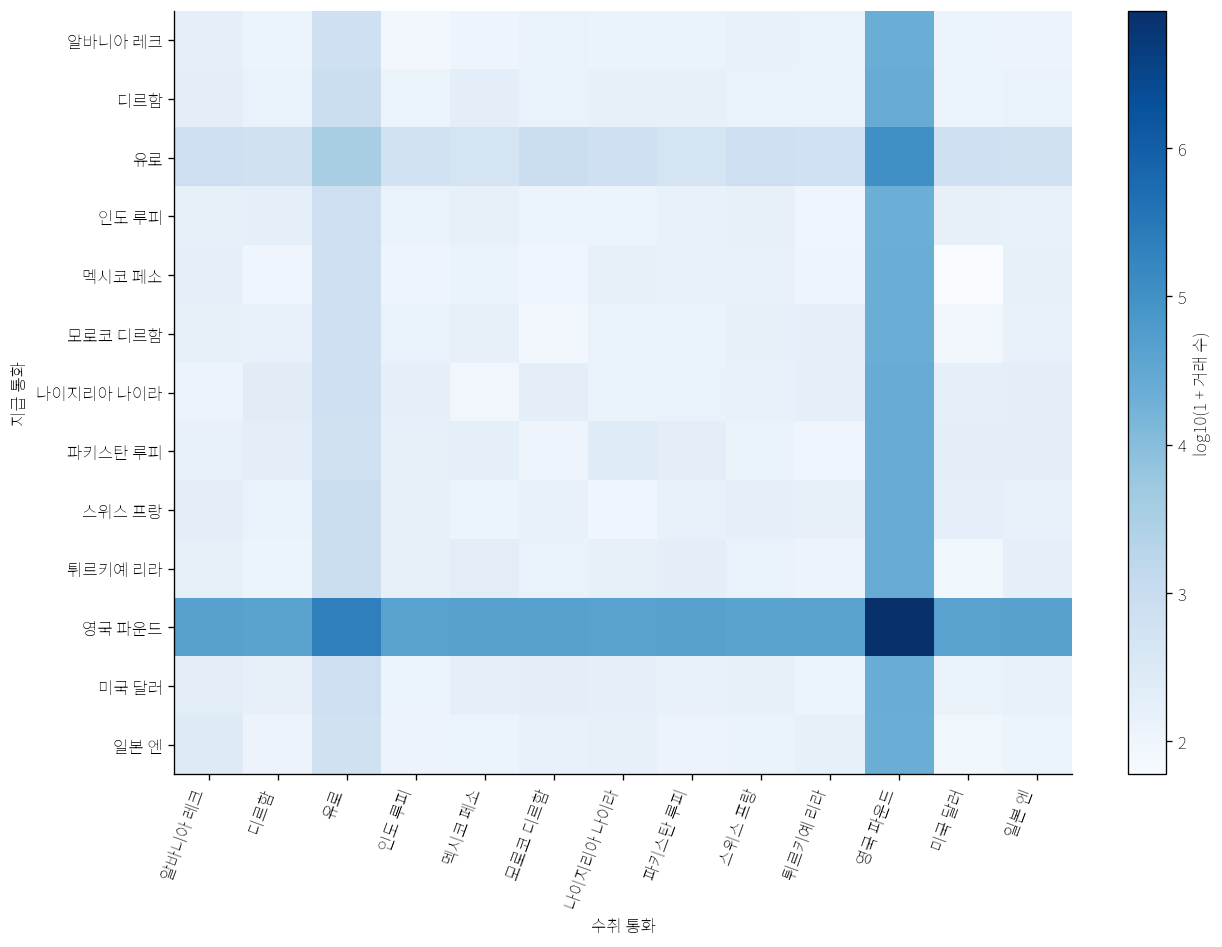

In [30]:
# 11-2. 송수신 통화 조합 히트맵
# pivot/pivot_table: 행·열 범주별 교차표를 만듭니다. fillna(0)은 없는 조합의 집계값을 0으로 표시합니다.
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
mat=pairs.pivot(index='source',columns='destination',values='transactions').fillna(0)
fig,ax=plt.subplots(figsize=(11,8))
im=ax.imshow(np.log10(1+mat),aspect='auto',cmap='Blues')
ax.set_xticks(range(len(mat.columns)),mat.columns,rotation=70,ha='right')
ax.set_yticks(range(len(mat.index)),mat.index)
ax.set_xlabel(right)
ax.set_ylabel(left)
fig.colorbar(im,ax=ax,label='log10(1 + 거래 수)')
그림저장('09_'+name)

### 11-3. 송수신 은행 위치 조합 상위 15개 표

위치 조합별 거래 수와 양성 수입니다. 위치는 은행 ID와 동일한 개념으로 가정하지 않습니다.

In [31]:
# 11-3. 송수신 은행 위치 조합 상위 15개 표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
(name, left, right) = ('location_pairs', 'Sender_bank_location', 'Receiver_bank_location')
pairs=조회(f'SELECT {ident(left)} AS source,{ident(right)} AS destination,count(*) AS transactions,sum(y)::BIGINT AS positives FROM tx GROUP BY 1,2',name)
표보기(pairs.sort_values('transactions',ascending=False).head(15))

,송신·지급 범주,수신·수취 범주,거래 수,양성 거래 수
0,영국,영국,8569083,6817
12,영국,파키스탄,37595,160
150,영국,오스트리아,37360,152
155,영국,모로코,37146,245
15,영국,일본,37130,76
149,영국,독일,37056,97
3,영국,프랑스,37043,75
5,영국,멕시코,36977,195
6,영국,알바니아,36788,213
145,영국,나이지리아,36579,236


### 11-4. 송수신 은행 위치 조합 히트맵

큰 범주와 작은 범주를 함께 보기 위해 색상을 로그 변환합니다.

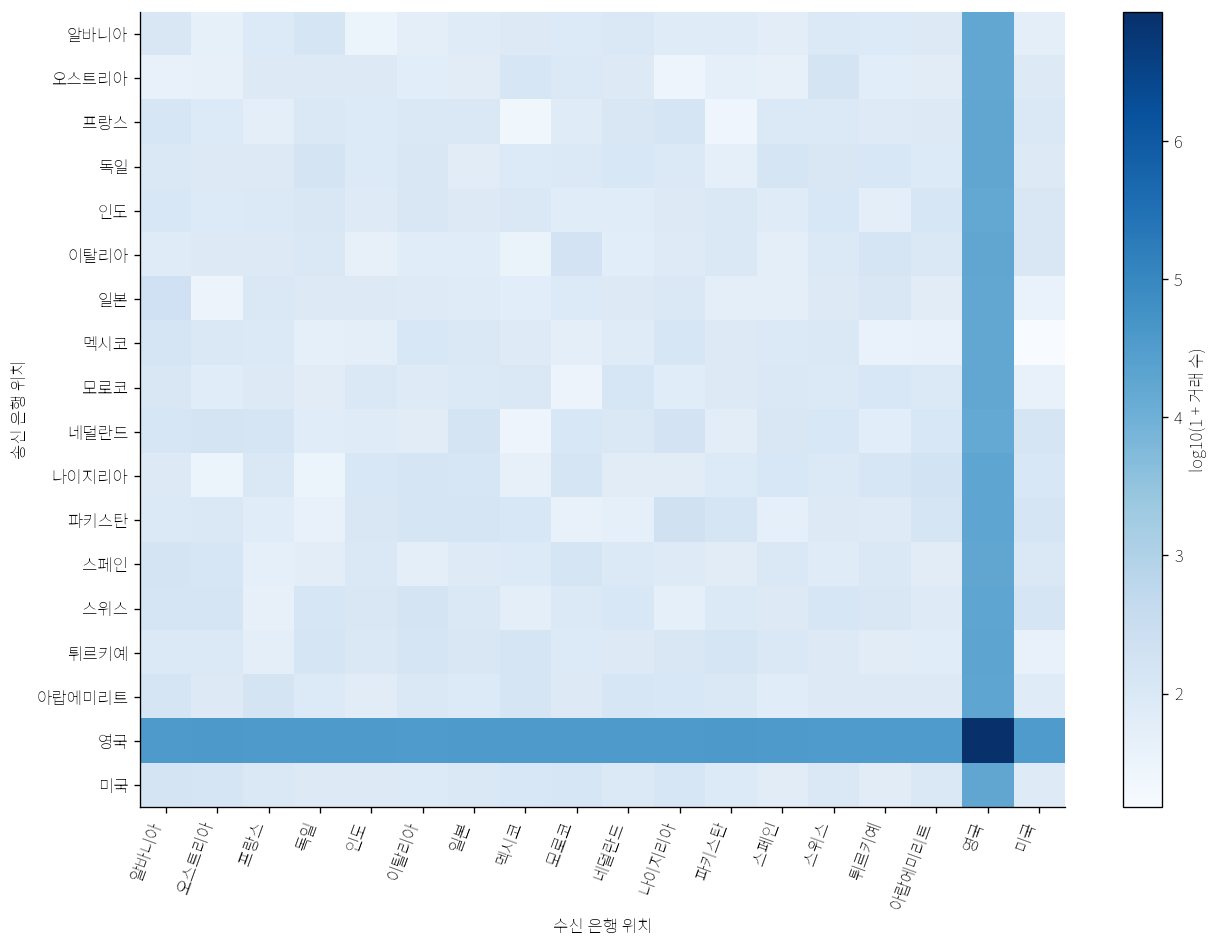

In [32]:
# 11-4. 송수신 은행 위치 조합 히트맵
# pivot/pivot_table: 행·열 범주별 교차표를 만듭니다. fillna(0)은 없는 조합의 집계값을 0으로 표시합니다.
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
mat=pairs.pivot(index='source',columns='destination',values='transactions').fillna(0)
fig,ax=plt.subplots(figsize=(11,8))
im=ax.imshow(np.log10(1+mat),aspect='auto',cmap='Blues')
ax.set_xticks(range(len(mat.columns)),mat.columns,rotation=70,ha='right')
ax.set_yticks(range(len(mat.index)),mat.index)
ax.set_xlabel(right)
ax.set_ylabel(left)
fig.colorbar(im,ax=ax,label='log10(1 + 거래 수)')
그림저장('09_'+name)

### 11-5. 통화 변경 × 위치 변경 교차표

두 변경 여부를 True/False로 조합하고 각 그룹의 양성 비율을 계산합니다.

In [33]:
# 11-5. 통화 변경 × 위치 변경 교차표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
relations=조회("""SELECT Payment_currency!=Received_currency AS currency_change,
    Sender_bank_location!=Receiver_bank_location AS location_change,
    count(*) AS transactions,sum(y)::BIGINT AS positives,100.0*sum(y)/count(*) AS positive_pct
    FROM tx GROUP BY 1,2 ORDER BY 1,2""",'cross_currency_location')
표보기(relations)

,통화 변경 여부,은행 위치 변경 여부,거래 수,양성 거래 수,양성 비율(%)
0,False,False,8414812,6177,0.073406
1,False,True,4178,39,0.933461
2,True,False,155692,651,0.418133
3,True,True,930170,3006,0.323167


## 12. 계좌 활동과 식별자 일관성
송신·수신 ID 합집합으로 계좌 수를 구하고, ID별로 서로 다른 은행 위치가 몇 개 관측되는지 확인합니다. 하나의 ID가 여러 위치에 등장한다면 ID의 전역 유일성·위치 컬럼 의미를 확인해야 합니다. 위치가 곧 은행 식별자라고 가정하지 않습니다.

활동도는 송신/수신에 등장한 횟수입니다. 자기 계좌 거래가 있으면 양쪽 역할을 각각 셉니다. 상위 계좌의 활동량 자체가 이상행동의 증거는 아닙니다.

### 12-1. 계좌 수·역할·활동도 요약표

unique_accounts는 송수신 ID 합집합, both_roles는 두 역할 모두 등장, multiple_locations는 여러 위치에서 관측된 ID 수입니다.

In [34]:
# 12-1. 계좌 수·역할·활동도 요약표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
con.execute("""CREATE OR REPLACE TABLE account_activity AS
    WITH endpoints AS (
      SELECT Sender_account AS account,Sender_bank_location AS location,y,'sender' AS role FROM tx
      UNION ALL SELECT Receiver_account,Receiver_bank_location,y,'receiver' FROM tx)
    SELECT account,count(*) AS endpoint_count,count(*) FILTER(WHERE role='sender') AS sent,
      count(*) FILTER(WHERE role='receiver') AS received,sum(y)::BIGINT AS positive_endpoints,
      count(DISTINCT location) AS locations FROM endpoints GROUP BY account""")
account_summary=조회("""SELECT count(*) AS unique_accounts,
    count(*) FILTER(WHERE sent>0 AND received>0) AS both_roles,
    count(*) FILTER(WHERE locations>1) AS multiple_locations,
    median(endpoint_count) AS median_activity,max(endpoint_count) AS max_activity FROM account_activity""",'account_summary')
표보기(account_summary)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,전체 고유 계좌 ID,송수신 모두 등장한 ID,여러 위치에 등장한 ID,계좌 활동 중앙값,계좌 활동 최댓값
0,855460,89521,6507,12.0,1498


### 12-2. 계좌 활동과 위치 수 분포 그래프

왼쪽은 송수신 등장 횟수 구간별 계좌 수, 오른쪽은 ID별 관측 위치 수입니다. 모두 계좌 수 축을 로그로 표시합니다.

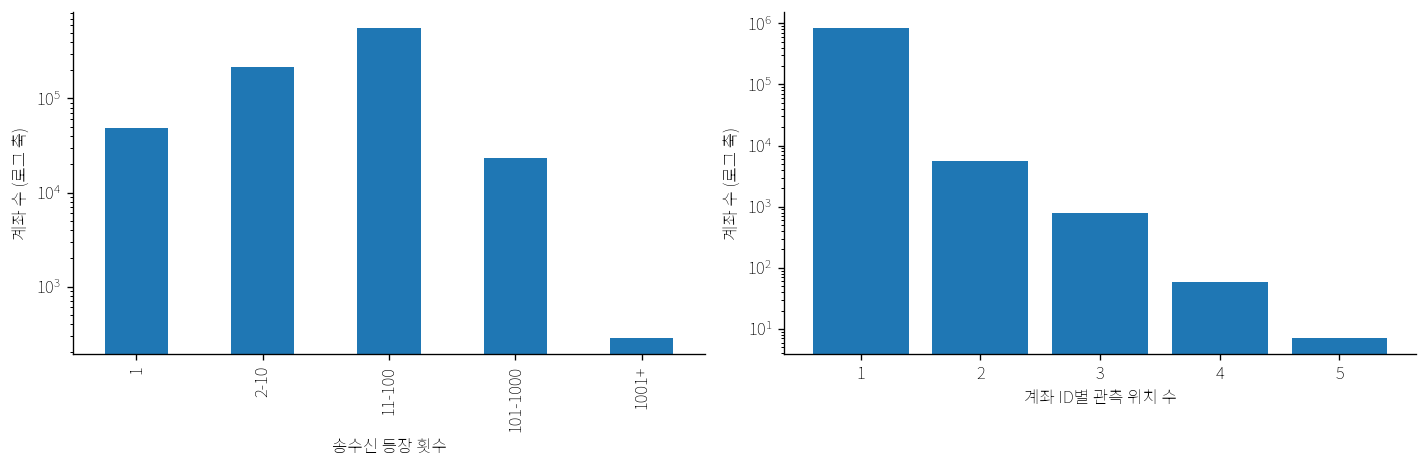

In [35]:
# 12-2. 계좌 활동과 위치 수 분포 그래프
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
location_counts=조회('SELECT locations,count(*) AS accounts FROM account_activity GROUP BY 1 ORDER BY 1','account_locations')
activity=조회("""SELECT CASE WHEN endpoint_count=1 THEN '1' WHEN endpoint_count<=10 THEN '2-10'
    WHEN endpoint_count<=100 THEN '11-100' WHEN endpoint_count<=1000 THEN '101-1000'
    ELSE '1001+' END AS bucket,count(*) AS accounts FROM account_activity GROUP BY 1""",'account_activity_bins')
activity=activity.set_index('bucket').reindex(['1','2-10','11-100','101-1000','1001+']).fillna(0)
fig,ax=plt.subplots(1,2,figsize=(12,4))
activity.plot.bar(y='accounts',logy=True,legend=False,ax=ax[0])
ax[0].set_ylabel('계좌 수 (로그 축)')
ax[0].set_xlabel('송수신 등장 횟수')
ax[1].bar(location_counts.locations,location_counts.accounts)
ax[1].set_yscale('log')
ax[1].set_xlabel('계좌 ID별 관측 위치 수')
ax[1].set_ylabel('계좌 수 (로그 축)')
그림저장('10_accounts')

### 12-3. 활동 상위 20개 계좌 표

sent/received는 송신/수신 거래 수, positive_endpoints는 양성 거래의 계좌 등장 횟수입니다. 자기 거래는 역할별로 집계됩니다.

In [36]:
# 12-3. 활동 상위 20개 계좌 표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
표보기(조회('SELECT * FROM account_activity ORDER BY endpoint_count DESC, account LIMIT 20','top_accounts'))

,계좌 ID,송수신 등장 횟수,송신 건수,수신 건수,양성 거래의 계좌 등장 횟수,관측 위치 수
0,2938210715,1498,753,745,6,1
1,4808614002,1491,754,737,8,1
2,5579295130,1490,751,739,8,1
3,8600542721,1489,738,751,8,1
4,2357599526,1481,749,732,8,1
5,4724445469,1467,731,736,0,1
6,9810335545,1467,742,725,6,1
7,6408343900,1465,735,730,8,1
8,3747015869,1464,730,734,9,1
9,9824280342,1463,731,732,9,1


## 13. 거래 쌍·동일 시각 거래
계좌 쌍은 방향이 있는 `(Sender_account, Receiver_account)`로 정의합니다. 같은 초에 여러 거래가 발생하면 거래 순서가 확정되지 않을 수 있습니다. 실시간 피처에서는 동률 시각을 어떻게 처리할지 정해야 하며, 일 마감 그래프와 실시간 탐지를 구분해야 합니다.

### 13-1. 방향성 계좌 쌍 요약표

송신→수신 쌍을 구분하여 고유 쌍 수, 단 한 번 거래한 쌍, 거래 횟수의 중앙값·최댓값을 표시합니다.

In [37]:
# 13-1. 방향성 계좌 쌍 요약표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
pair_summary=조회("""WITH p AS (SELECT Sender_account,Receiver_account,count(*) AS n FROM tx GROUP BY 1,2)
    SELECT count(*) AS directed_pairs,count(*) FILTER(WHERE n=1) AS single_transaction_pairs,
    median(n) AS median_pair_transactions,max(n) AS max_pair_transactions FROM p""",'pair_summary')
표보기(pair_summary)

,방향성 계좌 쌍 수,1회 거래 계좌 쌍,쌍별 거래 수 중앙값,쌍별 거래 수 최댓값
0,887497,105866,12.0,84


### 13-2. 동일 시각 거래 빈도표

transactions_at_same_second는 같은 초의 거래 수, timestamp_groups는 그러한 초의 개수, transactions는 해당 초들에 속한 전체 거래 수입니다.

In [38]:
# 13-2. 동일 시각 거래 빈도표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
concurrency=조회("""WITH t AS (SELECT ts,count(*) AS n FROM tx WHERE ts IS NOT NULL GROUP BY 1)
    SELECT n AS transactions_at_same_second,count(*) AS timestamp_groups,sum(n) AS transactions
    FROM t GROUP BY 1 ORDER BY 1""",'timestamp_concurrency')
표보기(concurrency)

,같은 초의 거래 수,해당 시각 그룹 수,거래 수
0,1,6248689,6248689.0
1,2,1286549,2573098.0
2,3,194111,582333.0
3,4,22283,89132.0
4,5,2087,10435.0
5,6,180,1080.0
6,7,11,77.0
7,8,1,8.0


### 13-3. 동일 시각 거래 분포 그래프

같은 초에 몇 건이 모이는지 로그 축으로 보여줍니다. 시간 동률 처리 규칙을 정할 때 참고합니다.

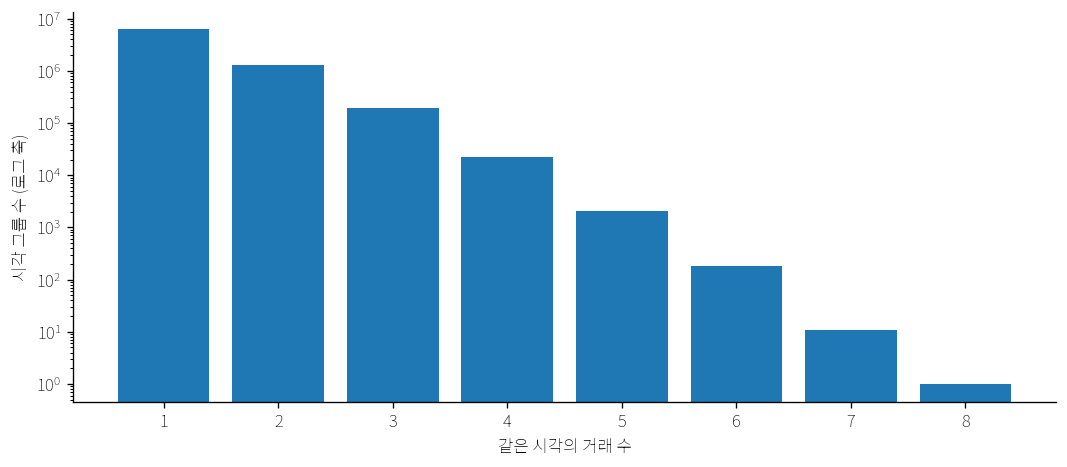

In [39]:
# 13-3. 동일 시각 거래 분포 그래프
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
plt.figure(figsize=(9,4))
plt.bar(concurrency.transactions_at_same_second,concurrency.timestamp_groups)
plt.yscale('log')
plt.xlabel('같은 시각의 거래 수')
plt.ylabel('시각 그룹 수 (로그 축)')
그림저장('11_concurrency')

## 14. 완전 중복과 동일 입력의 정답 충돌
완전 중복은 **12개 원본 컬럼 전체가 같은 행**입니다. 분석용 `row_id`를 제외하고 비교합니다. 별도로 라벨·유형을 제외한 입력이 같은 그룹에서 정답이 다른지 검사합니다. 해시 충돌 가능성이 있는 근사 비교가 아니라 실제 컬럼 값으로 그룹화합니다.

이 단계는 전체 데이터 정렬/그룹화 때문에 상대적으로 시간이 걸립니다. 중복이 발견돼도 이 노트북은 자동으로 삭제하지 않습니다.

### 14-1. 완전 중복 검사표

12개 원본 컬럼이 같은 그룹을 검사합니다. extra_rows는 첫 행을 제외한 초과 행, involved_rows는 중복 그룹 전체 행 수입니다.

In [40]:
# 14-1. 완전 중복 검사표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
fields=','.join(ident(x) for x in columns)
duplicates=조회(f"""SELECT count(*) AS duplicate_groups,coalesce(sum(n-1),0)::BIGINT AS extra_rows,
    coalesce(sum(n),0)::BIGINT AS involved_rows FROM
    (SELECT count(*) AS n FROM raw GROUP BY {fields} HAVING count(*)>1)""",'exact_duplicates')
표보기(duplicates)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,완전 중복 그룹 수,중복 초과 행 수,중복 관련 전체 행
0,0,0,0


### 14-2. 동일 입력의 라벨·유형 충돌표

라벨과 유형을 제외한 입력이 동일한 그룹에서 라벨이 달라지는지 확인합니다. 어떤 행도 삭제하지 않습니다.

In [41]:
# 14-2. 동일 입력의 라벨·유형 충돌표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
inputs=','.join(ident(x) for x in columns if x not in ['Is_laundering','Laundering_type'])
conflicting=조회(f"""SELECT count(*) FILTER(WHERE n>1) AS repeated_input_groups,
    count(*) FILTER(WHERE labels>1) AS conflicting_binary_labels,
    count(*) FILTER(WHERE types>1) AS multiple_types FROM
    (SELECT count(*) AS n,count(DISTINCT Is_laundering) AS labels,
    count(DISTINCT Laundering_type) AS types FROM raw GROUP BY {inputs})""",'input_conflicts')
표보기(conflicting)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,반복 입력 그룹 수,이진 정답 충돌 그룹,유형이 여러 개인 그룹
0,0,0,0


## 15. 시간 분할을 만들기 전 분포 점검 (참고용 60/20/20)
아래는 **SAML-D의 관측된 전체 날짜를 시간순으로 나누는 예시**이며, HI-Large 실험 설정을 변경하지 않습니다. 처음·마지막 날짜도 포함합니다. 꼬리 제외 기준이나 정규화용 선행 기간을 아직 정하지 않았으므로 최종 학습 분할이 아닙니다.

날짜 수를 60/20/20에 가깝게 나누며 거래 건수 비율은 다릅니다. 경계별 양성 수와 유형 수, 앞 구간에 없던 양성 유형을 점검합니다. 미래누수를 막으려면 정규화·피처 선정·임계값 설정에 테스트 데이터를 사용하지 않아야 합니다. 이 노트북의 전체 기간 통계는 탐색용입니다.

### 15-1. SAML-D 예시 시간 분할 요약표

날짜순 60/20/20 예시의 기간·일수·거래 수·양성 비율을 보여줍니다. row_share_pct는 일수가 아닌 거래 수 기준 비중입니다.

In [42]:
# 15-1. SAML-D 예시 시간 분할 요약표
# groupby: 같은 범주끼리 묶습니다. sum=합계, count/size=개수, nunique=고유값 수입니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
days=daily.day.sort_values().tolist()
a=int(len(days)*.6)
b=int(len(days)*.8)
assert 0<a<b<len(days)
VAL_START,TEST_START=days[a],days[b]
daily['example_split']=np.where(daily.day<VAL_START,'train',np.where(daily.day<TEST_START,'val','test'))
example=daily.groupby('example_split').agg(start=('day','min'),end=('day','max'),days=('day','size'),transactions=('transactions','sum'),positives=('positives','sum')).reindex(['train','val','test'])
example['positive_pct']=100*example.positives/example.transactions
example['row_share_pct']=100*example.transactions/example.transactions.sum()
표보기(example)

,시작일,종료일,날짜 수,거래 수,양성 거래 수,양성 비율(%),거래 건수 비중(%)
예시 분할,,,,,,,
학습,2022-10-07,2023-04-16,192,5707316,5751,0.100765,60.046343
검증,2023-04-17,2023-06-19,64,1899527,1986,0.104552,19.984814
테스트,2023-06-20,2023-08-23,65,1898009,2136,0.112539,19.968843


### 15-2. 예시 분할별 양성 유형 건수 표

Train/Val/Test별 양성 유형 건수입니다. 학습 구간에 없는 유형이 이후에 나타나는지도 다음 셀에서 확인합니다.

In [43]:
# 15-2. 예시 분할별 양성 유형 건수 표
# 조회(): SQL 조건으로 원본 전체를 집계합니다. SELECT=컬럼 선택, WHERE=조건, GROUP BY=그룹별 집계입니다.
# pivot/pivot_table: 행·열 범주별 교차표를 만듭니다. fillna(0)은 없는 조합의 집계값을 0으로 표시합니다.
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
example.to_csv(OUTPUT/'example_split_summary.csv')
by_type=조회(f"""SELECT CASE WHEN ts<{sqlstr(VAL_START)}::TIMESTAMP THEN 'train'
    WHEN ts<{sqlstr(TEST_START)}::TIMESTAMP THEN 'val' ELSE 'test' END AS split,
    Laundering_type,count(*) AS positives FROM tx WHERE y=1 AND ts IS NOT NULL GROUP BY 1,2""",'example_split_types')
표보기(by_type.pivot(index='Laundering_type',columns='split',values='positives').fillna(0).astype(int))

분할,테스트,학습,검증
거래 유형,,,
Behavioural_Change_1,90,207,97
Behavioural_Change_2,93,178,74
Bipartite,42,258,83
Cash_Withdrawal,273,779,282
Cycle,50,235,97
Deposit-Send,208,562,175
Fan_In,64,187,113
Fan_Out,76,92,69
Gather-Scatter,100,215,39


### 15-3. 예시 분할과 일별 양성 비율 그래프

배경색이 예시 분할 구간입니다. 이 코드는 HI-Large 학습 설정이나 기존 모델을 변경하지 않습니다.

학습 구간에 없고 이후에 등장한 양성 유형: []


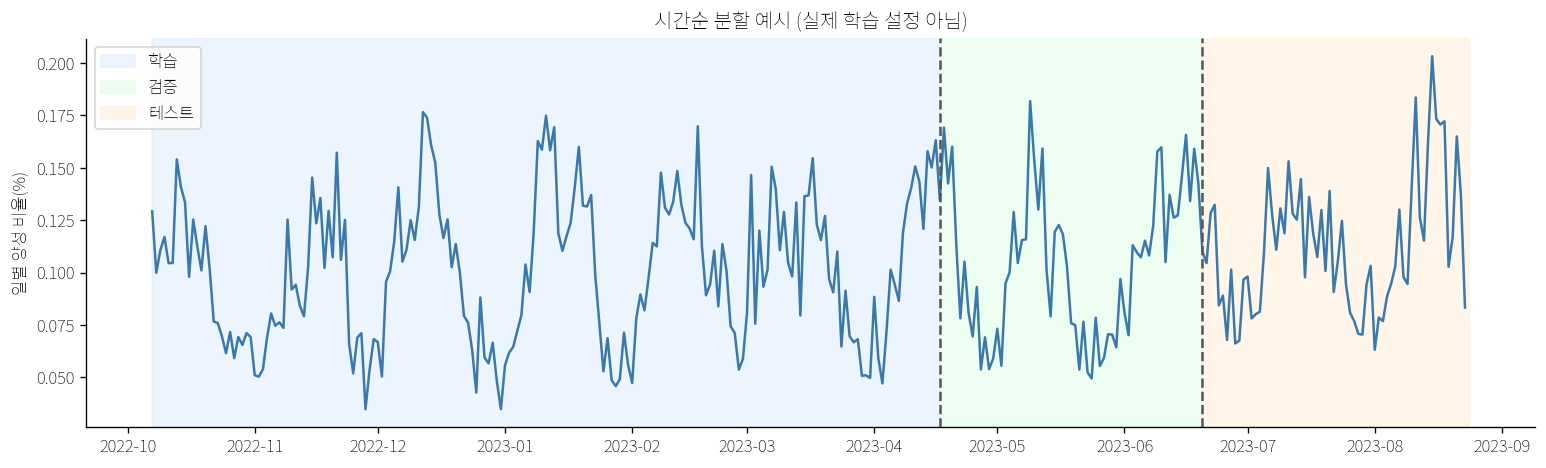

In [44]:
# 15-3. 예시 분할과 일별 양성 비율 그래프
# 그래프의 데이터는 앞 표와 동일합니다. 로그 축 여부와 비율의 분모를 확인하세요.
seen=set(by_type.loc[by_type.split=='train','Laundering_type'])
print('학습 구간에 없고 이후에 등장한 양성 유형:',[한글(x) for x in sorted(set(by_type.Laundering_type)-seen)])
fig,ax=plt.subplots(figsize=(13,4))
ax.plot(daily.day,daily.positive_pct,color='#3979ac')
for left,right,color,label in [(days[0],VAL_START,'#dbeafe','Train'),(VAL_START,TEST_START,'#dcfce7','Val'),(TEST_START,days[-1]+pd.Timedelta(days=1),'#ffedd5','Test')]:
    ax.axvspan(left,right,color=color,alpha=.5,label=label)
ax.axvline(VAL_START,color='#555',ls='--')
ax.axvline(TEST_START,color='#555',ls='--')
ax.set_ylabel('일별 양성 비율(%)')
ax.set_title('시간순 분할 예시 (실제 학습 설정 아님)')
ax.legend()
그림저장('12_example_split')

## 16. 집계 검증·자동 요약·산출물
각 집계표의 합계가 원본 행 수·양성 수와 일치하는지 검사합니다. 날짜·금액 변환 실패가 있다면 해당 행이 시간·금액 통계에서 빠진다는 사실을 반영합니다. 원본 파일이 실행 도중 바뀌었는지도 크기·수정 시각으로 확인합니다.

아래의 `assert` 실패는 무시하지 말고 앞 단계 입력과 결측 현황을 확인하세요. 기존 결과 파일의 숫자를 정답으로 고정하지 않고 이번 실행의 집계끼리 대조합니다.

### 16-1. 집계 합계 검증표

원본과 라벨·유형·시간·통화·금액 집계 합계를 대조하고 원본 파일 변경 여부를 검사합니다. 모든 항목이 True여야 합니다.

In [45]:
# 16-1. 집계 합계 검증표
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
checks={
    'label_counts':int(labels.transactions.sum())==N,
    'type_counts':int(types.transactions.sum())==N,
    'type_positive_counts':int(types.loc[types.y==1,'transactions'].sum())==POS,
    'daily_valid_timestamp_counts':int(daily.transactions.sum())==N-int(summary.invalid_datetime.iloc[0]),
    'currency_counts':int(category_tables['Payment_currency'].transactions.sum())==N,
    'payment_counts':int(category_tables['Payment_type'].transactions.sum())==N,
    'amount_valid_counts':int(amount.transactions.sum())==N-int(summary.invalid_amount.iloc[0]),
    'source_unchanged':SOURCE_STAT==(SOURCE.stat().st_size,SOURCE.stat().st_mtime_ns),
}
assert all(checks.values()),checks
(OUTPUT/'validation.json').write_text(json.dumps(checks,ensure_ascii=False,indent=2)+'\n')
run={'source':str(SOURCE),'source_bytes':SOURCE_STAT[0],'source_mtime_ns':SOURCE_STAT[1],
     'rows':N,'positives':POS,'positive_pct':100*POS/N,
     'finished_utc':datetime.now(timezone.utc).isoformat(),'elapsed_seconds':round(time.time()-START,1),
     'duckdb_version':duckdb.__version__,'pandas_version':pd.__version__,'checks':checks}
(OUTPUT/'run_summary.json').write_text(json.dumps(run,ensure_ascii=False,indent=2)+'\n')
표보기(pd.Series(checks,name='passed').to_frame())

,검사 통과
라벨별 건수 합계,True
유형별 건수 합계,True
유형별 양성 합계,True
일별 유효 날짜 건수,True
통화별 건수 합계,True
지급 방식별 건수 합계,True
유효 금액 건수 합계,True
원본 변경 없음,True


### 16-2. 이번 실행의 핵심 결과

실제 실행에서 계산한 규모·양성 비율·계좌 수·중복 수를 요약합니다.

In [46]:
# 16-2. 이번 실행의 핵심 결과
# 표보기(): 계산값은 그대로 두고 화면의 컬럼·범주 이름만 한글로 바꿉니다.
표보기(Markdown(f"""**분석 완료**

- 전체 **{N:,}건**, 양성 **{POS:,}건 ({100*POS/N:.4f}%)**.
- 고유 계좌 ID **{int(account_summary.unique_accounts.iloc[0]):,}개**, 여러 은행 위치에 등장하는 ID **{int(account_summary.multiple_locations.iloc[0]):,}개**.
- 완전 중복 초과 행 **{int(duplicates.extra_rows.iloc[0]):,}건**, 동일 입력의 이진 라벨 충돌 **{int(conflicting.conflicting_binary_labels.iloc[0]):,}그룹**.
- 검증 **{len(checks)}개 통과**, 산출물: `{OUTPUT}`.
"""))
con.close()
print('DB 연결을 닫았습니다. SQL을 다시 실행하려면 첫 설정 셀부터 실행하세요.')

**분석 완료**

- 전체 **9,504,852건**, 양성 **9,873건 (0.1039%)**.
- 고유 계좌 ID **855,460개**, 여러 은행 위치에 등장하는 ID **6,507개**.
- 완전 중복 초과 행 **0건**, 동일 입력의 이진 라벨 충돌 **0그룹**.
- 검증 **8개 통과**, 산출물: `/workspace/kimi/Claude_GNN/final_model/raw_eda/saml_d/notebook_outputs`.


DB 연결을 닫았습니다. SQL을 다시 실행하려면 첫 설정 셀부터 실행하세요.


## 해석 체크리스트
- `Is_laundering`과 `Laundering_type`은 모델 입력에서 제외합니다.
- 타입별 거래 건수는 사건 수가 아닙니다. 원본에 없는 작전 ID를 추정해 사실처럼 사용하지 않습니다.
- 전체 데이터의 분위수·계좌 활동 집계를 과거 시점의 피처로 그대로 가져오지 않습니다.
- 계좌 ID의 전역 식별 기준과 `Amount`의 통화 의미는 별도 데이터 명세와 대조합니다.
- 실시간 탐지라면 거래 시점 이후의 같은 날 거래도 미래 정보입니다. 일 마감 그래프와 구별합니다.
- 예시 분할은 분포를 관찰하기 위한 것입니다. 모델 실험 전에 정규화 기간·제외 기간·평가 프로토콜을 별도로 고정합니다.

생성된 모든 그림은 `notebook_outputs/`에 PNG와 PDF로 저장됩니다. 셀 출력이 저장된 노트북은 재실행하지 않고도 열람할 수 있습니다.